# Big Data Lab Work

### Installing Dependencies

In [3]:
# # %pip install --force-reinstall "ipykernel==6.28.0"
# %pip uninstall -y ipykernel
# %pip install "ipykernel==6.28.0"
import ipykernel
print(ipykernel.__version__)
import polars as pl

6.28.0


Jojie works best with older version of polars. Latest version causes kernel to crash on import

In [4]:
# # %pip install polars
# !python -m pip uninstall -y polars polars-runtime-32 polars-runtime-64 polars-lts-cpu
# !python -m pip install "polars==0.20.31"

### Viewing Datasets through Bash/Terminal

In [5]:
!ls -lh /mnt/data/public/polymarket/

total 568K
-rwxrwxr-x+ 1 root root 9.5K Mar 27 16:52 README.md
-rwxrwxr-x+ 1 root root 523K Mar 27 16:52 banner.png
drwxrwxr-x+ 2 root root 4.0K Apr 26 11:42 features
drwxrwxr-x+ 2 root root 4.0K Apr 26 11:42 labels
drwxrwxr-x+ 2 root root 4.0K Apr 26 11:42 orderbook
drwxrwxr-x+ 2 root root 4.0K Apr 26 11:42 snapshots


In [6]:
!nvidia-smi

No devices were found


In [7]:
!ls -lh /mnt/data/public/polymarket/features

total 31M
-rwxrwxr-x+ 1 root root 31M Mar 27 16:52 ml_features_1m_v2.parquet


In [8]:
ls -lh /mnt/data/public/polymarket/labels

total 48M
-rwxrwxr-x+ 1 root root 15M Mar 27 16:52 market_targets.parquet*
-rwxrwxr-x+ 1 root root 33M Mar 27 16:52 trades.parquet*


In [9]:
ls -lh /mnt/data/public/polymarket/orderbook | head -5

total 35G
-rwxrwxr-x+ 1 root root 2.0G Mar 27 16:53 orderbook_2026-03-06.parquet*
-rwxrwxr-x+ 1 root root 2.1G Mar 27 16:55 orderbook_2026-03-07.parquet*
-rwxrwxr-x+ 1 root root 2.2G Mar 27 16:58 orderbook_2026-03-08.parquet*
-rwxrwxr-x+ 1 root root 1.3G Mar 27 17:00 orderbook_2026-03-09.parquet*


In [10]:
ls -lh /mnt/data/public/polymarket/snapshots | head -5

total 3.9G
-rwxrwxr-x+ 1 root root 302M Mar 27 17:32 snapshots_2026-03-06.parquet*
-rwxrwxr-x+ 1 root root 224M Mar 27 17:32 snapshots_2026-03-07.parquet*
-rwxrwxr-x+ 1 root root 228M Mar 27 17:32 snapshots_2026-03-08.parquet*
-rwxrwxr-x+ 1 root root  81M Mar 27 17:33 snapshots_2026-03-09.parquet*


In [11]:
!du -sch /mnt/data/public/polymarket/*

12K	/mnt/data/public/polymarket/README.md
524K	/mnt/data/public/polymarket/banner.png
31M	/mnt/data/public/polymarket/features
48M	/mnt/data/public/polymarket/labels
35G	/mnt/data/public/polymarket/orderbook
3.9G	/mnt/data/public/polymarket/snapshots
39G	total


In [12]:
# path = "/mnt/data/public/polymarket/labels/market_targets.parquet"
path = "/mnt/data/public/polymarket/features/ml_features_1m_v2.parquet"

# Polar Dataframe Version
df_market = pl.scan_parquet(path)
df_market.limit(100).collect().to_pandas()
# df_market.collect().describe()

,market_id,minute_bar,close_mid,mean_spread,close_spread,bar_volatility,total_volume,buy_volume,sell_volume,trade_count,order_flow_imbalance,target,return_1m,bid_depth,ask_depth,depth_imbalance
0,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,2026-03-06 00:00:00+00:00,0.2850,0.453750,0.450,0.0050,0.0,0.0,0.0,0,0.0,0,0.017857,287.79,3845.07,-0.860731
1,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,2026-03-06 00:01:00+00:00,0.2850,0.450000,0.450,0.0000,0.0,0.0,0.0,0,0.0,0,0.000000,287.79,3845.07,-0.860731
2,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,2026-03-06 00:02:00+00:00,0.2900,0.443333,0.440,0.0050,0.0,0.0,0.0,0,0.0,0,0.017544,287.79,3845.07,-0.860731
3,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,2026-03-06 00:03:00+00:00,0.2900,0.440000,0.440,0.0000,0.0,0.0,0.0,0,0.0,0,0.000000,287.79,3845.07,-0.860731
4,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,2026-03-06 00:04:00+00:00,0.2900,0.440000,0.440,0.0000,0.0,0.0,0.0,0,0.0,0,0.000000,366.80,8838.88,-0.920310
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,2026-03-06 03:04:00+00:00,0.4850,0.970000,0.970,0.0000,0.0,0.0,0.0,0,0.0,0,0.000000,10.80,186.75,-0.890661
96,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,2026-03-06 03:05:00+00:00,0.4850,0.970000,0.970,0.0000,0.0,0.0,0.0,0,0.0,0,0.000000,10.80,186.75,-0.890661
97,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,2026-03-06 03:21:00+00:00,0.0050,0.010000,0.010,0.0000,0.0,0.0,0.0,0,0.0,0,-0.989691,10.80,186.75,-0.890661
98,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,2026-03-06 03:22:00+00:00,0.0050,0.010000,0.010,0.0000,0.0,0.0,0.0,0,0.0,0,0.000000,10.80,186.75,-0.890661


#### Reading Trades and Market Targets

Market_Targets.parquet

In [13]:
path = "/mnt/data/public/polymarket/labels/market_targets.parquet"

# Polar Dataframe Version
df_market = pl.scan_parquet(path)
df_market.limit(10000).collect().to_pandas()


,condition_id,question,category,end_date,closed,uma_status,volume,liquidity,clob_token_id_yes,clob_token_id_no,target
0,0xb48621f7eba07b0a3eeabc6afb09ae42490239903997...,BitBoy convicted?,,2026-03-31T12:00:00Z,False,,2.266330e+05,9631.43077,7546712961590831958303147464265888547913563043...,3842963720267267286970642336860752782302644680...,NaN
1,0x9c1a953fe92c8357f1b646ba25d983aa83e90c525992...,Russia-Ukraine Ceasefire before GTA VI?,,2026-07-31T12:00:00Z,False,,1.403228e+06,100309.56630,8501497159083948713316135768103773293754490207...,2527312495175492857904889758552137141356236738...,NaN
2,0x1fad72fae204143ff1c3035e99e7c0f65ea8d5cd9bd1...,New Rihanna Album before GTA VI?,,2026-07-31T12:00:00Z,False,,6.751036e+05,32729.52530,9802249026969240999812649612759703249033407008...,5383155306188300653073987728410593891972140877...,NaN
3,0x50ddb9cd80d5c271664a2ebb7fcaed1d0a148d82c8e8...,New Playboi Carti Album before GTA VI?,,2026-07-31T12:00:00Z,False,,7.094616e+05,29544.93060,8827504006008477337655718797221526751304984864...,9437620581602295554297963554227993296735991576...,NaN
4,0x32b09f6390252b37d674501527e709016d55581b2c1e...,Will Jesus Christ return before GTA VI?,,2026-07-31T12:00:00Z,False,,1.027764e+07,831771.48120,9043581125366557801495738082650599253005407769...,9238862908268180562280162270352898292254328635...,NaN
...,...,...,...,...,...,...,...,...,...,...,...
9995,0xc28ce947b32874ea66e4e0d531b0858b32c2a21075e8...,Will Toronto FC win the 2026 MLS Cup?,,2026-12-19T00:00:00Z,False,,1.151501e+03,40311.50015,4233599054631062124744519538793279953538732656...,8676333290708374411863073846594942719876369205...,NaN
9996,0x25bf49c93f524a86fcb640a93ccabec6cd377efb54f4...,Will Vancouver Whitecaps FC win the 2026 MLS Cup?,,2026-12-19T00:00:00Z,False,,7.658383e+04,11531.45230,7921736744269023863891748633335710564424495066...,8457400049793448365402188396089716779032080875...,NaN
9997,0x0bd51ac08ee1cc3ebf14ab952df7de25b2fa16e24b85...,"Will Russia enter Pokrovskoe by March 31, 2026?",,2026-03-31T00:00:00Z,False,,2.662030e+04,10340.61384,1011881901953184711288340044259734495916635569...,4880752939288715356310764164113851975080074887...,NaN
9998,0xef3f70a6f99ed1efe45d10e43f2d99a4a3737e9da65a...,"Will Russia enter Khatnie by March 31, 2026?",,2026-03-31T00:00:00Z,False,,3.348529e+04,5345.50451,1114157695591402234327456572593971437386699805...,8577454711909914968756678140071260455922799600...,NaN


Trades.parquet  
Individual Trade Executions on Resolved Markets

In [14]:
path = "/mnt/data/public/polymarket/labels/trades.parquet"

# Polar Dataframe Version
df_market = pl.scan_parquet(path)
df_market.limit(100).collect().to_pandas()
# df_market.collect().describe()


,condition_id,side,outcome,price,size,timestamp,asset
0,0x0000dbb9f89318fa1324d4eed3dbc1ff192e764138c7...,BUY,No,0.790000,37.974682,1773535485,5475751391326417034909210895395778447254138036...
1,0x0000dbb9f89318fa1324d4eed3dbc1ff192e764138c7...,BUY,Yes,0.850000,5.000000,1773554079,8945166516904290673857818127174024824733820142...
2,0x0000dbb9f89318fa1324d4eed3dbc1ff192e764138c7...,BUY,Yes,0.850000,1.176466,1773569429,8945166516904290673857818127174024824733820142...
3,0x0000dbb9f89318fa1324d4eed3dbc1ff192e764138c7...,BUY,Yes,0.820000,1.219511,1773594139,8945166516904290673857818127174024824733820142...
4,0x0000dbb9f89318fa1324d4eed3dbc1ff192e764138c7...,BUY,No,0.540179,20.363634,1773636999,5475751391326417034909210895395778447254138036...
...,...,...,...,...,...,...,...
95,0x00028df20b436a1302c1bb0a3857cb314cd1d955bf49...,BUY,Yes,0.117000,9.400000,1773467031,6203533918419524766542070754953293312455087712...
96,0x00028df20b436a1302c1bb0a3857cb314cd1d955bf49...,BUY,Yes,0.120000,5.000000,1773467977,6203533918419524766542070754953293312455087712...
97,0x00028df20b436a1302c1bb0a3857cb314cd1d955bf49...,BUY,No,0.964000,5.000000,1773469173,8052752854383609253127056003138630746422603315...
98,0x00028df20b436a1302c1bb0a3857cb314cd1d955bf49...,BUY,No,0.963000,5.000000,1773469915,8052752854383609253127056003138630746422603315...


In [15]:
n_rows = df_market.select(pl.len()).collect().item()
print(n_rows)

4126076


#### Reading OrderBook

In [16]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("View Polymarket Orderbook Parquet")
    .getOrCreate()
)

path = "/mnt/data/public/polymarket/orderbook/orderbook_2026-03-06.parquet"

df = spark.read.parquet(path)

# Show schema
df.printSchema()

# Show first 20 rows without truncating columns
df.show(20, truncate=False)

# Optional: see column names
print(df.columns)

# Optional: count rows, can be slow for 2GB+
print("Row count:", df.count())

root
 |-- timestamp_received: long (nullable = true)
 |-- timestamp_created_at: long (nullable = true)
 |-- market_id: string (nullable = true)
 |-- best_bid: float (nullable = true)
 |-- best_ask: float (nullable = true)
 |-- change_price: float (nullable = true)
 |-- change_size: float (nullable = true)
 |-- change_side: string (nullable = true)
 |-- token_id: string (nullable = true)
 |-- spread: float (nullable = true)
 |-- mid_price: float (nullable = true)

+------------------+--------------------+------------------------------------------------------------------+--------+--------+------------+-----------+-----------+-----------------------------------------------------------------------------+------------+---------+
|timestamp_received|timestamp_created_at|market_id                                                         |best_bid|best_ask|change_price|change_size|change_side|token_id                                                                     |spread      |mid_price|
+-

In [17]:
df.limit(10).toPandas()

,timestamp_received,timestamp_created_at,market_id,best_bid,best_ask,change_price,change_size,change_side,token_id,spread,mid_price
0,1772755441639,1772755441679,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,0.009,0.013,0.009,1000.900024,BUY,4455468110807479331389362642427847115009165823...,0.004,0.011
1,1772755573852,1772755578267,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,0.009,0.013,0.133,0.000000,SELL,4455468110807479331389362642427847115009165823...,0.004,0.011
2,1772755574100,1772755578472,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,0.009,0.013,0.133,40.000000,SELL,4455468110807479331389362642427847115009165823...,0.004,0.011
3,1772755577386,1772755579670,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,0.009,0.013,0.043,256.700012,SELL,4455468110807479331389362642427847115009165823...,0.004,0.011
4,1772755658205,1772755658227,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,0.009,0.013,0.009,900.900024,BUY,4455468110807479331389362642427847115009165823...,0.004,0.011
5,1772755964391,1772755964470,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,0.009,0.013,0.154,0.000000,SELL,4455468110807479331389362642427847115009165823...,0.004,0.011
6,1772756105891,1772756105922,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,0.009,0.013,0.009,1000.900024,BUY,4455468110807479331389362642427847115009165823...,0.004,0.011
7,1772756146031,1772756146049,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,0.009,0.013,0.699,200.000000,SELL,4455468110807479331389362642427847115009165823...,0.004,0.011
8,1772756200595,1772756200608,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,0.009,0.013,0.043,250.000000,SELL,4455468110807479331389362642427847115009165823...,0.004,0.011
9,1772756240758,1772756240799,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,0.009,0.013,0.699,0.000000,SELL,4455468110807479331389362642427847115009165823...,0.004,0.011


In [18]:
# df.groupBy("update_type") \
#   .count() \
#   .orderBy(col("count").desc()) \
#   .show(truncate=False)

#### Reading Snapshots

In [19]:
path = "/mnt/data/public/polymarket/snapshots/snapshots_2026-03-06.parquet"

df2 = spark.read.parquet(path)
df2.limit(10).toPandas()

,timestamp_received,timestamp_created_at,market_id,update_type,data
0,1772755479569,1772755479636,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,book_snapshot,"{""update_type"": ""book_snapshot"", ""market_id"": ..."
1,1772757306842,1772757306884,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,book_snapshot,"{""update_type"": ""book_snapshot"", ""market_id"": ..."
2,1772758741660,1772758741701,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,book_snapshot,"{""update_type"": ""book_snapshot"", ""market_id"": ..."
3,1772758749082,1772758749140,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,book_snapshot,"{""update_type"": ""book_snapshot"", ""market_id"": ..."
4,1772757678461,1772757678492,0x0008043c3ed513ecff7ee64380fc943dc73eb3dfb667...,book_snapshot,"{""update_type"": ""book_snapshot"", ""market_id"": ..."
5,1772757825635,1772757825916,0x0008043c3ed513ecff7ee64380fc943dc73eb3dfb667...,book_snapshot,"{""update_type"": ""book_snapshot"", ""market_id"": ..."
6,1772758000770,1772758000792,0x0008043c3ed513ecff7ee64380fc943dc73eb3dfb667...,book_snapshot,"{""update_type"": ""book_snapshot"", ""market_id"": ..."
7,1772758045967,1772758045980,0x0008043c3ed513ecff7ee64380fc943dc73eb3dfb667...,book_snapshot,"{""update_type"": ""book_snapshot"", ""market_id"": ..."
8,1772758055224,1772758055235,0x0008043c3ed513ecff7ee64380fc943dc73eb3dfb667...,book_snapshot,"{""update_type"": ""book_snapshot"", ""market_id"": ..."
9,1772756288585,1772756288645,0x004230fb1f54a139d50ba2041e062a01461c931a6725...,book_snapshot,"{""update_type"": ""book_snapshot"", ""market_id"": ..."


# Big Data Mining

### Loading Data
Set Subsample Size and Number of Days of Data to Calculate Here

In [20]:
# %pip install polars

To Speed Up Our Run we will be using Polars Dataframe for our Data Mining and Wrangling   
Note: For Jojie, a lower version needs to be installed  
!python -m pip install "polars==0.20.31"  
More about Polars Here https://pola.rs/
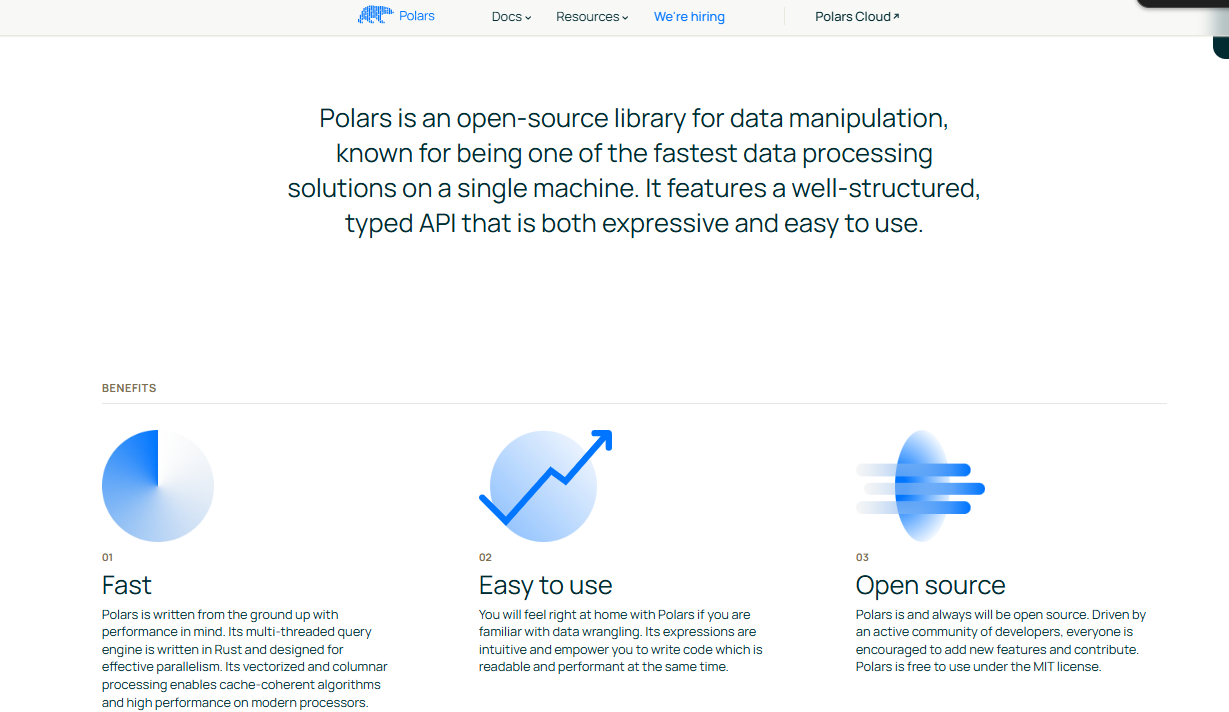

In [21]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator, AutoMinorLocator, MaxNLocator


Select what files to open and run

In [22]:
import os
import re
from datetime import datetime

# Reuse existing spark session
# spark = SparkSession.builder...getOrCreate()

DATA_DIR = "/mnt/data/public/polymarket"
ob_dir = f"{DATA_DIR}/orderbook"
snap_dir = f"{DATA_DIR}/snapshots"

# -----------------------------
# Date filter options
# -----------------------------
# Option A: inclusive range
START_DATE = "2026-03-06"   # set None to disable
END_DATE   = "2026-03-06"   # set None to disable

# Option B: explicit date set (takes priority if not None)
INCLUDE_DATES = None
# Example:
# INCLUDE_DATES = {"2026-03-01", "2026-03-03", "2026-03-06"}

date_pattern = re.compile(r"(\d{4}-\d{2}-\d{2})")

def extract_date(fname: str):
    m = date_pattern.search(fname)
    return m.group(1) if m else None

def keep_file_by_date(fname: str):
    d = extract_date(fname)
    if d is None:
        return False

    if INCLUDE_DATES is not None:
        return d in INCLUDE_DATES

    if START_DATE is None and END_DATE is None:
        return True

    dt = datetime.strptime(d, "%Y-%m-%d").date()
    if START_DATE is not None and dt < datetime.strptime(START_DATE, "%Y-%m-%d").date():
        return False
    if END_DATE is not None and dt > datetime.strptime(END_DATE, "%Y-%m-%d").date():
        return False
    return True

# Orderbook files filtered by date
ob_files_all = sorted([f for f in os.listdir(ob_dir) if f.endswith(".parquet")])
ob_files = [f for f in ob_files_all if keep_file_by_date(f)]
assert ob_files, "No orderbook parquet files matched your date filter."

print(f"Selected orderbook files: {len(ob_files)}")
for f in ob_files[:10]:
    print(" ", f)
if len(ob_files) > 10:
    print(" ...")

# Build full paths and read with Spark
ob_paths = [f"{ob_dir}/{f}" for f in ob_files]

Selected orderbook files: 1
  orderbook_2026-03-06.parquet


## Exploring Market Targets Data
Note: Documents All Unique Market ids and the event question of each id.
Dataset also contains the size of the market as liquidity (Number of Active Trades in the Orderbook) and Volume (Number of shares traded)

- Volume. The amount/size of actually traded shares as a dollar value 
	- Shares held by people who are not currently selling are not counted in volume.
	- High volume means a lot of trades actually occurred.
    - Volume cumulatively increases as more trades happen. Usually measured in a time window

- Liquidity. Shares currently offered to Buy or Sell. High liquidity means many shares are available to trade.
- Target shows market Resolution. 1 for Yes and 0 for no.

Loading Data

In [23]:
# path = "/mnt/data/public/polymarket/snapshots/snapshots_2026-03-06.parquet"
path = "/mnt/data/public/polymarket/labels/market_targets.parquet"

# # Spark Dataframe Version
# df3 = spark.read.parquet(path)
# df3.limit(100).toPandas()

# # Polar Dataframe Version
# df3 = pl.scan_parquet(path)
# df3.limit(10).collect().to_pandas()

# # Spark Dataframe Version
# df3 = spark.read.parquet(path)
# df3.limit(100).toPandas()

# Polar Dataframe Version
df_market = pl.scan_parquet(path)
df_market.limit(10).collect().to_pandas()

,condition_id,question,category,end_date,closed,uma_status,volume,liquidity,clob_token_id_yes,clob_token_id_no,target
0,0xb48621f7eba07b0a3eeabc6afb09ae42490239903997...,BitBoy convicted?,,2026-03-31T12:00:00Z,False,,2.266330e+05,9631.43077,7546712961590831958303147464265888547913563043...,3842963720267267286970642336860752782302644680...,NaN
1,0x9c1a953fe92c8357f1b646ba25d983aa83e90c525992...,Russia-Ukraine Ceasefire before GTA VI?,,2026-07-31T12:00:00Z,False,,1.403228e+06,100309.56630,8501497159083948713316135768103773293754490207...,2527312495175492857904889758552137141356236738...,NaN
2,0x1fad72fae204143ff1c3035e99e7c0f65ea8d5cd9bd1...,New Rihanna Album before GTA VI?,,2026-07-31T12:00:00Z,False,,6.751036e+05,32729.52530,9802249026969240999812649612759703249033407008...,5383155306188300653073987728410593891972140877...,NaN
3,0x50ddb9cd80d5c271664a2ebb7fcaed1d0a148d82c8e8...,New Playboi Carti Album before GTA VI?,,2026-07-31T12:00:00Z,False,,7.094616e+05,29544.93060,8827504006008477337655718797221526751304984864...,9437620581602295554297963554227993296735991576...,NaN
4,0x32b09f6390252b37d674501527e709016d55581b2c1e...,Will Jesus Christ return before GTA VI?,,2026-07-31T12:00:00Z,False,,1.027764e+07,831771.48120,9043581125366557801495738082650599253005407769...,9238862908268180562280162270352898292254328635...,NaN
5,0x84f8b70331323c2fba97d7ceaa9a35fb645a0770d0db...,Trump out as President before GTA VI?,,2026-07-31T12:00:00Z,False,,5.564197e+05,106972.10780,1089997232078979418764529355570116040679173891...,6453357980929752557903360996363493950101333285...,NaN
6,0x7b49b9bacb5f435bc10f3b100ff59e2fdd346f7f92a9...,Will China invades Taiwan before GTA VI?,,2026-07-31T12:00:00Z,False,,1.511593e+06,134101.15460,2169513887321137545105556677010768232549420672...,1751642757638338275636846765620625820649001595...,NaN
7,0xbb57ccf5853a85487bc3d83d04d669310d28c6c81075...,Will bitcoin hit $1m before GTA VI?,,2026-07-31T12:00:00Z,False,,3.769555e+06,471575.75659,1052675680736590682173119939019279624762984406...,9186316211830866306973392404315918600510655878...,NaN
8,0xcccb7e7613a087c132b69cbf3a02bece3fdcb824c1da...,GTA VI released before June 2026?,,2026-05-31T12:00:00Z,False,,1.287859e+07,53483.91376,8441400852834915183759801017793514978104486628...,1092895690865089341423232221029747690750744944...,NaN
9,0xf398b0e5016eeaee9b0885ed84012b6dc91269ac10d3...,Will Harvey Weinstein be sentenced to no priso...,,2025-12-31T12:00:00Z,False,,2.790603e+05,2759.69112,2432780396064590937814904181069734364075212260...,8648847862367718835287280131850714376118896746...,NaN


In [24]:
# from pathlib import Path
# import shutil

# # source file (choose one)
# # src = Path("/mnt/data/public/polymarket/snapshots/snapshots_2026-03-06.parquet")
# src = Path("/mnt/data/public/polymarket/labels/market_targets.parquet")

# # destination in current working directory
# dst = Path.cwd() / src.name

# shutil.copy2(src, dst)
# print(f"Copied to: {dst.resolve()}")

### Filtering Market Targets

Filtering Condition_id/Market_id into Higher Liquidity and Volume Markets  
Removing Dead Markets

Rows before:  123,895
Rows after:   2,633
Rows removed: 121,262 (97.87%)


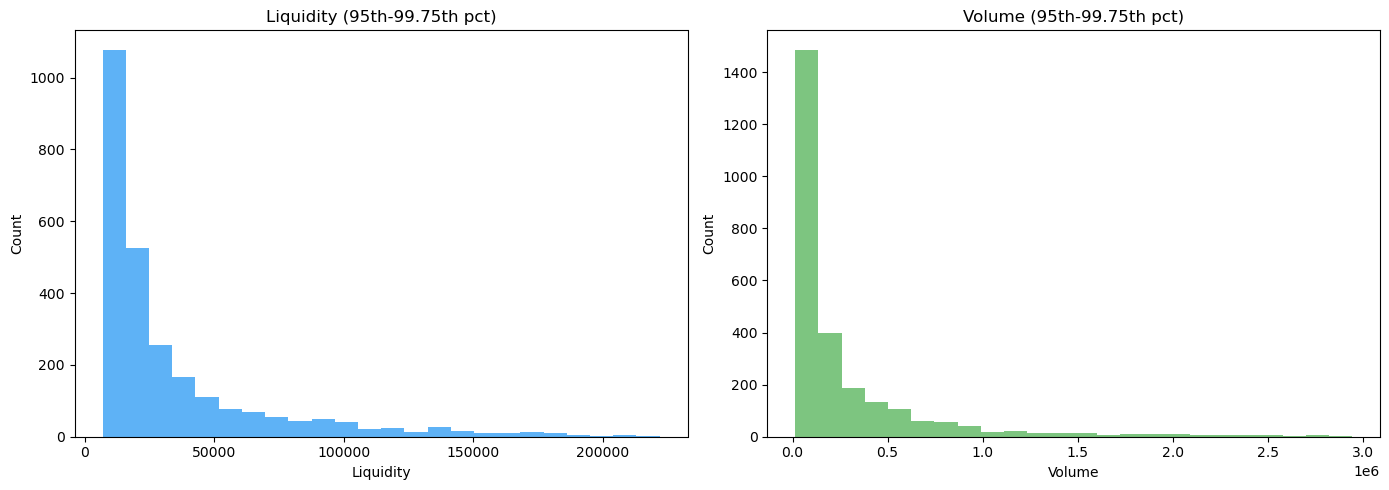

In [25]:
import numpy as np
import matplotlib.pyplot as plt

market_df = df_market.collect() if isinstance(df_market, pl.LazyFrame) else df_market

# keep middle 98% (1st to 99th percentile)
p_low, p_high = 95, 99.75
# p_low, p_high = 0, 100

liq_all = market_df["liquidity"].drop_nulls().to_numpy()
vol_all = market_df["volume"].drop_nulls().to_numpy()

liq_min, liq_max = np.percentile(liq_all, [p_low, p_high])
vol_min, vol_max = np.percentile(vol_all, [p_low, p_high])

before_rows = market_df.height

filtered = market_df.filter(
    pl.col("liquidity").is_between(liq_min, liq_max, closed="both") &
    pl.col("volume").is_between(vol_min, vol_max, closed="both")
)

after_rows = filtered.height
removed_rows = before_rows - after_rows
removed_pct = (removed_rows / before_rows * 100) if before_rows else 0.0

print(f"Rows before:  {before_rows:,}")
print(f"Rows after:   {after_rows:,}")
print(f"Rows removed: {removed_rows:,} ({removed_pct:.2f}%)")


liq = filtered["liquidity"].to_numpy()
vol = filtered["volume"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(liq, bins=24, color="#42A5F5", alpha=0.85, edgecolor="none")
axes[0].set_title(f"Liquidity ({p_low}th-{p_high}th pct)")
axes[0].set_xlabel("Liquidity")
axes[0].set_ylabel("Count")

axes[1].hist(vol, bins=24, color="#66BB6A", alpha=0.85, edgecolor="none")
axes[1].set_title(f"Volume ({p_low}th-{p_high}th pct)")
axes[1].set_xlabel("Volume")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


**Filtering Observation**  
A Large Majority of the Market Have Little to No Liquidity and Volume. We can classify these as dead markets or markets with little activity and most likely give no meaningful information

Using 1 day only considering markets with 97.5% to 99.75% of the liquidity and Volume Value
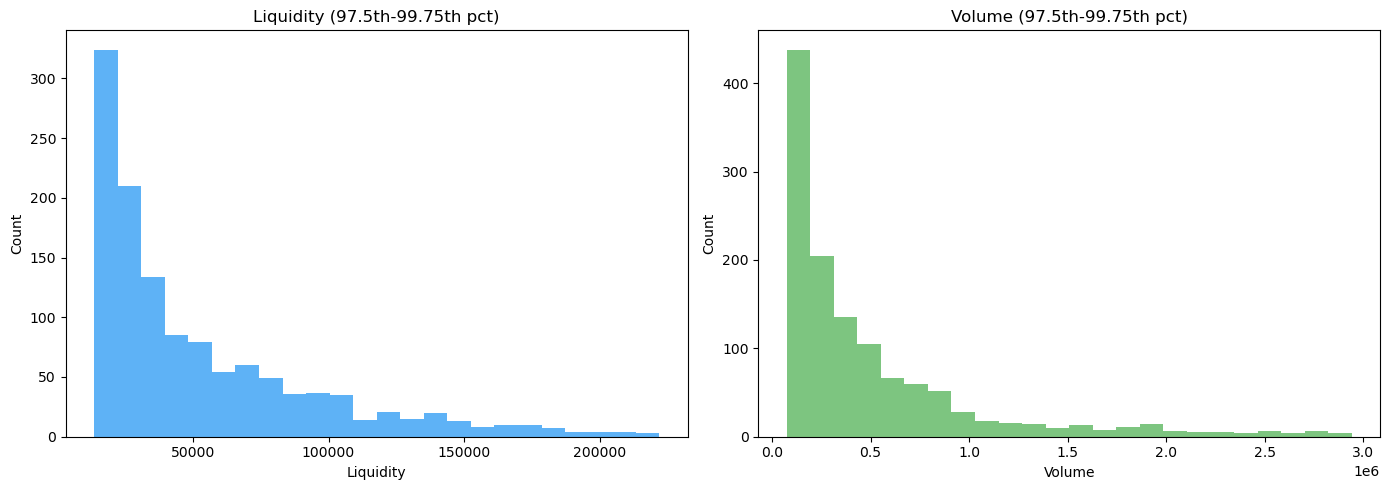

Using 1 day file all data
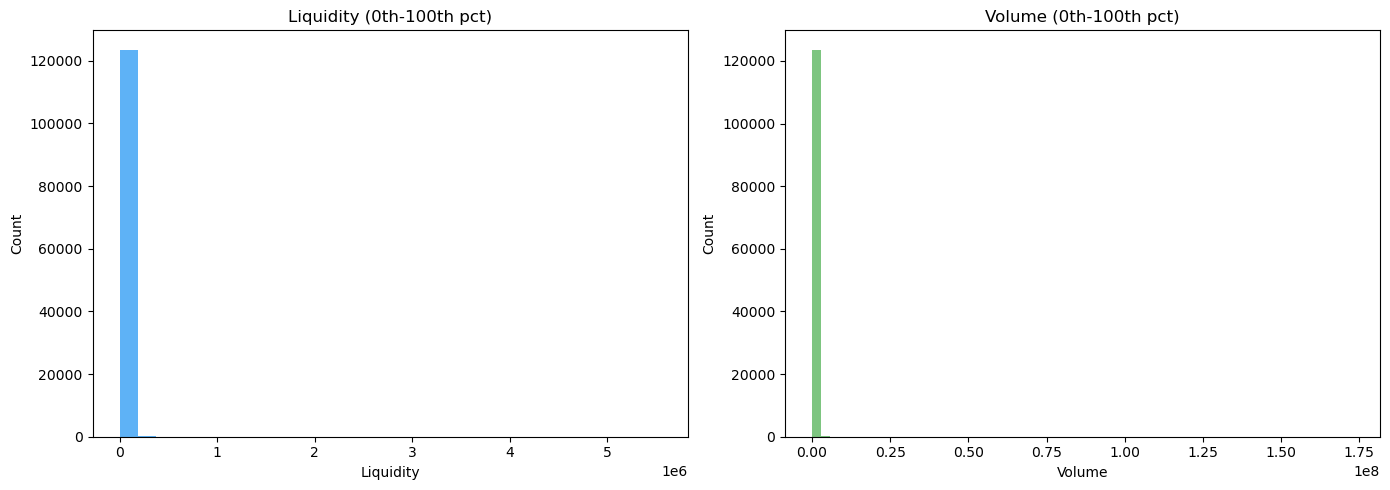

In [26]:
# Polar Dataframe Version
filtered.to_pandas()

,condition_id,question,category,end_date,closed,uma_status,volume,liquidity,clob_token_id_yes,clob_token_id_no,target
0,0xb48621f7eba07b0a3eeabc6afb09ae42490239903997...,BitBoy convicted?,,2026-03-31T12:00:00Z,False,,2.266330e+05,9631.43077,7546712961590831958303147464265888547913563043...,3842963720267267286970642336860752782302644680...,NaN
1,0x9c1a953fe92c8357f1b646ba25d983aa83e90c525992...,Russia-Ukraine Ceasefire before GTA VI?,,2026-07-31T12:00:00Z,False,,1.403228e+06,100309.56630,8501497159083948713316135768103773293754490207...,2527312495175492857904889758552137141356236738...,NaN
2,0x1fad72fae204143ff1c3035e99e7c0f65ea8d5cd9bd1...,New Rihanna Album before GTA VI?,,2026-07-31T12:00:00Z,False,,6.751036e+05,32729.52530,9802249026969240999812649612759703249033407008...,5383155306188300653073987728410593891972140877...,NaN
3,0x50ddb9cd80d5c271664a2ebb7fcaed1d0a148d82c8e8...,New Playboi Carti Album before GTA VI?,,2026-07-31T12:00:00Z,False,,7.094616e+05,29544.93060,8827504006008477337655718797221526751304984864...,9437620581602295554297963554227993296735991576...,NaN
4,0x84f8b70331323c2fba97d7ceaa9a35fb645a0770d0db...,Trump out as President before GTA VI?,,2026-07-31T12:00:00Z,False,,5.564197e+05,106972.10780,1089997232078979418764529355570116040679173891...,6453357980929752557903360996363493950101333285...,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2628,0xc815bca05a1d27a502bac245c3cdfb9c9027ec5f7816...,Counter-Strike: DashSkins vs UNO MILLE - Map 1...,,2026-03-27T04:25:00Z,False,proposed,2.933615e+04,57674.85522,9445400797661453297128573276425481050662771060...,1010104560676723400933713322949216011371152886...,NaN
2629,0xaf3559b87ea95e1ff40c29690c95fd858e946f77f4fa...,Counter-Strike: DashSkins vs UNO MILLE - Map 2...,,2026-03-27T04:25:00Z,False,proposed,1.850142e+04,44375.60017,1127185076412122155736916934565970181146114654...,3563674522474910604314647701894581358914040948...,NaN
2630,0xf964d61c05f4580daa9f78af744075897bb9881efe4d...,Spread: Pistons (-4.5),,2026-03-26T23:00:00Z,False,,1.972726e+06,7125.80560,4629905000372077321478898286292190226871521290...,6527490867199577822766678982115367006078666607...,NaN
2631,0x0dad5e9e46dade73149fdd3b3236c51f1b18ede8d325...,Kings vs. Magic: O/U 231.5,,2026-03-26T23:00:00Z,False,,2.477657e+05,12757.27250,5868357147306465615677408518581279613729933972...,4414190276287562042110694617859242281562437300...,NaN


## Exploring Market Targets: Topic Bucketing
- Polymarket Questions involve a wide range topic categories from politics, to entertainment, to memes etc. In order to observe how the market behaves across different topics, we will attempt to classify each question using NLP.
- Here we attempt to categorize the markets using hugging face transformer with facebook model facebook/bart-large-mnli" for a zero-shot classification
- this helps to study the behavior of the markets by category/topic and if underlying behaviors emerge from those observations
- we set the categories and the transformer then finds the probabilities for each topic to match each classifier
- topic discovery was conducted in a seperate notebook using NMF Topic Modelling Approach
- NOTE: RUN ONLY ON JOJIE CPU. Transformer labeling is about half a minute per row

View Here to know more about Transformers for Zero-Shot Classification https://huggingface.co/docs/transformers/v4.25.1/index
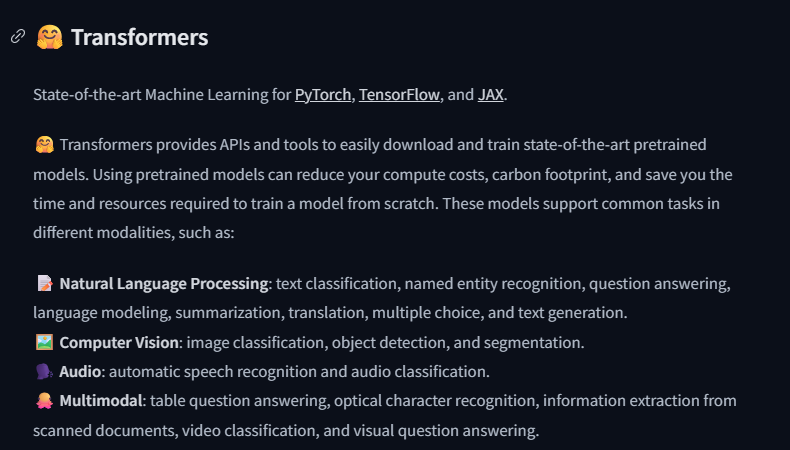

In [27]:
# Polar Dataframe Version
filtered.head(5).to_pandas()

,condition_id,question,category,end_date,closed,uma_status,volume,liquidity,clob_token_id_yes,clob_token_id_no,target
0,0xb48621f7eba07b0a3eeabc6afb09ae42490239903997...,BitBoy convicted?,,2026-03-31T12:00:00Z,False,,2.266330e+05,9631.43077,7546712961590831958303147464265888547913563043...,3842963720267267286970642336860752782302644680...,NaN
1,0x9c1a953fe92c8357f1b646ba25d983aa83e90c525992...,Russia-Ukraine Ceasefire before GTA VI?,,2026-07-31T12:00:00Z,False,,1.403228e+06,100309.56630,8501497159083948713316135768103773293754490207...,2527312495175492857904889758552137141356236738...,NaN
2,0x1fad72fae204143ff1c3035e99e7c0f65ea8d5cd9bd1...,New Rihanna Album before GTA VI?,,2026-07-31T12:00:00Z,False,,6.751036e+05,32729.52530,9802249026969240999812649612759703249033407008...,5383155306188300653073987728410593891972140877...,NaN
3,0x50ddb9cd80d5c271664a2ebb7fcaed1d0a148d82c8e8...,New Playboi Carti Album before GTA VI?,,2026-07-31T12:00:00Z,False,,7.094616e+05,29544.93060,8827504006008477337655718797221526751304984864...,9437620581602295554297963554227993296735991576...,NaN
4,0x84f8b70331323c2fba97d7ceaa9a35fb645a0770d0db...,Trump out as President before GTA VI?,,2026-07-31T12:00:00Z,False,,5.564197e+05,106972.10780,1089997232078979418764529355570116040679173891...,6453357980929752557903360996363493950101333285...,NaN


In [28]:
# !pip install transformers torch

In [29]:
# import polars as pl
# import pandas as pd
# from transformers import pipeline

Classify Polymarket   
- Uses Hugging Face Transformer to Classifty Quesions based on Embeddings to get a probabily for the best matched candidate labels for each Question.
- Zero-shot Classification
- 3 Labels are selected for each question and ranked based on their probabilities/likelihoods of being correct.

In [30]:
# # 1) Load question lookup
# # labels = pl.read_parquet("slt3a/Lab 1/data/market_targets.parquet")
# labels = pl.read_parquet("data/market_targets.parquet")
# labels_lu = (
#     labels
#     .select(["condition_id", "question"])
#     .unique(subset=["condition_id"])
# )

# # 2) Attach question text to your filtered table
# filtered_with_q = (
#     filtered
#     .join(labels_lu, on="condition_id", how="left")
#     .filter(pl.col("question").is_not_null())
# )

# # 3) Convert to pandas for easy iteration
# pdf = filtered_with_q.select([
#     "condition_id", "question", "volume", "liquidity", "target"
# ]).to_pandas()

# # Optional: dedupe repeated questions per condition_id before classifying
# # pdf_unique = pdf.drop_duplicates(subset=["condition_id"]).copy() # RUNS ENTIRE DATASET
# # pdf_unique = pdf.drop_duplicates(subset=["condition_id"]).head(500).copy() # TEST RUN on smaller dataset
# pdf_unique = (
#     pdf
#     .drop_duplicates(subset=["condition_id"])
#     .iloc[2100:] # SET LIMIT HERE
#     .copy()
# )
# # 4) Zero-shot classifier
# classifier = pipeline(
#     "zero-shot-classification",
#     model="facebook/bart-large-mnli",
#     device=0 # 0 to use GPU and -1 for CPU. GPU only works in Jojie
# )

# candidate_labels = ["politics", "entertainment","sports", "crypto", "economy", "world events", "culture", "science", "finance", "others"]

# # # 5) Classify (top label + score)
# # def classify_question(q):
# #     r = classifier(q, candidate_labels=candidate_labels, multi_label=False)
# #     return pd.Series({
# #         "pred_label": r["labels"][0],
# #         "pred_score": r["scores"][0]
# #     })
# # 5) Classify (top 3 labels + scores)
# def classify_question(q):
#     r = classifier(str(q), candidate_labels=candidate_labels, multi_label=False)
#     return pd.Series({
#         "top1_label": r["labels"][0], "top1_score": r["scores"][0],
#         "top2_label": r["labels"][1], "top2_score": r["scores"][1],
#         "top3_label": r["labels"][2], "top3_score": r["scores"][2],
#     })

# top3 = pdf_unique["question"].apply(classify_question)
# pdf_unique = pd.concat([pdf_unique, top3], axis=1)

# out = pdf.merge(
#     pdf_unique[[
#         "condition_id",
#         "top1_label", "top1_score",
#         "top2_label", "top2_score",
#         "top3_label", "top3_score"
#     ]],
#     on="condition_id",
#     how="left"
# )

# # out.head(10)
# # out.write_parquet("slt3a/Lab 1/data/market_targets_classified.parquet")
# # pl.from_pandas(out).write_parquet("slt3a/Lab 1/data/market_targets_classified.parquet")

In [31]:
# Computing Time it Takes to Complete
# print(len(filtered))
rows = (len(filtered)-1500)/1.89
print(rows) # Rows considered
(rows)/(10/46.6)/60/60 # hours to complete run

599.4708994708996


0.77598177542622

Save Extracted Files

In [32]:
# pl.from_pandas(out).write_parquet("data/market_targets_classified.parquet")
# out.head(10)

Combine and Load Classified Data

In [ ]:
# import polars as pl
# from pathlib import Path

# base = Path("slt3a/Lab 1/data")

# batch_files = [
#     base / "market_targets_classified_500.parquet",
#     base / "market_targets_classified_500_1500.parquet",
#     base / "market_targets_classified_1500_2100.parquet",
#     base / "market_targets_classified_2100_.parquet",
# ]

# combined = pl.concat([pl.read_parquet(f) for f in batch_files], how="vertical_relaxed")

# # one row per condition_id (keep highest-confidence top1 if overlaps exist)
# combined_one = (
#     combined
#     .sort(["condition_id", "top1_score"], descending=[False, True])
#     .group_by("condition_id", maintain_order=True)
#     .agg([
#         pl.col("question").drop_nulls().first().alias("question"),
#         pl.col("volume").drop_nulls().first().alias("volume"),
#         pl.col("liquidity").drop_nulls().first().alias("liquidity"),
#         pl.col("target").drop_nulls().first().alias("target"),
#         pl.col("top1_label").drop_nulls().first().alias("top1_label"),
#         pl.col("top1_score").drop_nulls().first().alias("top1_score"),
#         pl.col("top2_label").drop_nulls().first().alias("top2_label"),
#         pl.col("top2_score").drop_nulls().first().alias("top2_score"),
#         pl.col("top3_label").drop_nulls().first().alias("top3_label"),
#         pl.col("top3_score").drop_nulls().first().alias("top3_score"),
#     ])
# )

# out_path = base / "market_targets_classified_all.parquet"
# combined_one.write_parquet(out_path)

# print(f"Rows: {combined_one.height:,}")
# print(f"Saved: {out_path.resolve()}")


Rows: 2,633
Saved: /mnt/processed/private/msds2026/slt3a/Lab 1/data/market_targets_classified_all.parquet


### Exploring Classified Market Questions

Load Data

In [67]:
# Load Data
# path = "slt3a/Lab 1/data/market_targets_classified_all.parquet"
path = "slt3a/Lab 1/data/market_targets_classified_all.parquet"

# Polar Dataframe Version
df_market_class = pl.scan_parquet(path)
# df_market_class.limit(10).collect().to_pandas()
# df_market_class.collect().to_pandas()

# Remove exact duplicate rows
df_market_class_dedup = (
    pl.scan_parquet(path)
    .unique(subset=["condition_id"], keep="first")
)
# materialize if needed
df_market_class_dedup.collect().to_pandas()

,condition_id,question,volume,liquidity,target,top1_label,top1_score,top2_label,top2_score,top3_label,top3_score
0,0xdb68062324c27327e9cd4b21b1dd0deadbc4b860abb8...,MegaETH market cap (FDV) >$6B one day after la...,2.250395e+06,64904.29732,NaN,crypto,0.742144,finance,0.078717,economy,0.053422
1,0x45a92c8b378085a254cf1678e006bc1046a60e04be19...,Will LaNorris Sellers be the first pick of the...,4.704829e+04,13551.42283,NaN,sports,0.839727,others,0.039403,culture,0.026951
2,0x9aa0c5ff4963e6e6c0a9fdd2c53a1fa9c4383fab0d26...,Will Epstein Data Set 13 be released by March 31?,1.704540e+04,7603.49670,NaN,others,0.310736,science,0.255465,culture,0.078358
3,0x055ed7282ced4939bdb10778104f2e0e5934e507ad42...,Will Linda Nosková win the 2026 Women’s French...,1.677880e+04,23116.78870,NaN,sports,0.715036,others,0.074851,world events,0.051112
4,0x974b8c1c84376fb5d58ec1fca05f0977c599693e5ce5...,Will Grigor Dimitrov win the 2026 Men's French...,3.340653e+04,18268.07178,NaN,sports,0.750504,others,0.065400,world events,0.056635
...,...,...,...,...,...,...,...,...,...,...,...
2628,0x495e6b49e7397bb4e6f8ce69e246ccb33b744678bd9b...,"Will Russia invade a NATO country by June 30, ...",2.233858e+06,57104.79666,NaN,world events,0.359966,others,0.213012,politics,0.144600
2629,0x5264a64154942898bebe8a052cef01dc3e4396591777...,Will the Democratic Party win the MS-03 House ...,1.775646e+04,13423.82384,NaN,politics,0.689466,others,0.085457,culture,0.055093
2630,0x23e817f30871533d3bd7da01e68b802c5fccb8f44f05...,Will Jannik Sinner win the 2026 Men's French O...,1.093363e+05,31490.45610,NaN,sports,0.777105,world events,0.040545,others,0.034722
2631,0x7ee722a07e0f84405f1267bc1c84eb95bd6348454453...,Will 5 Fed rate cuts happen in 2026?,7.492531e+05,91505.85043,NaN,others,0.340668,finance,0.207423,economy,0.167891


Visualizing Composition of High liquidity and volume markets

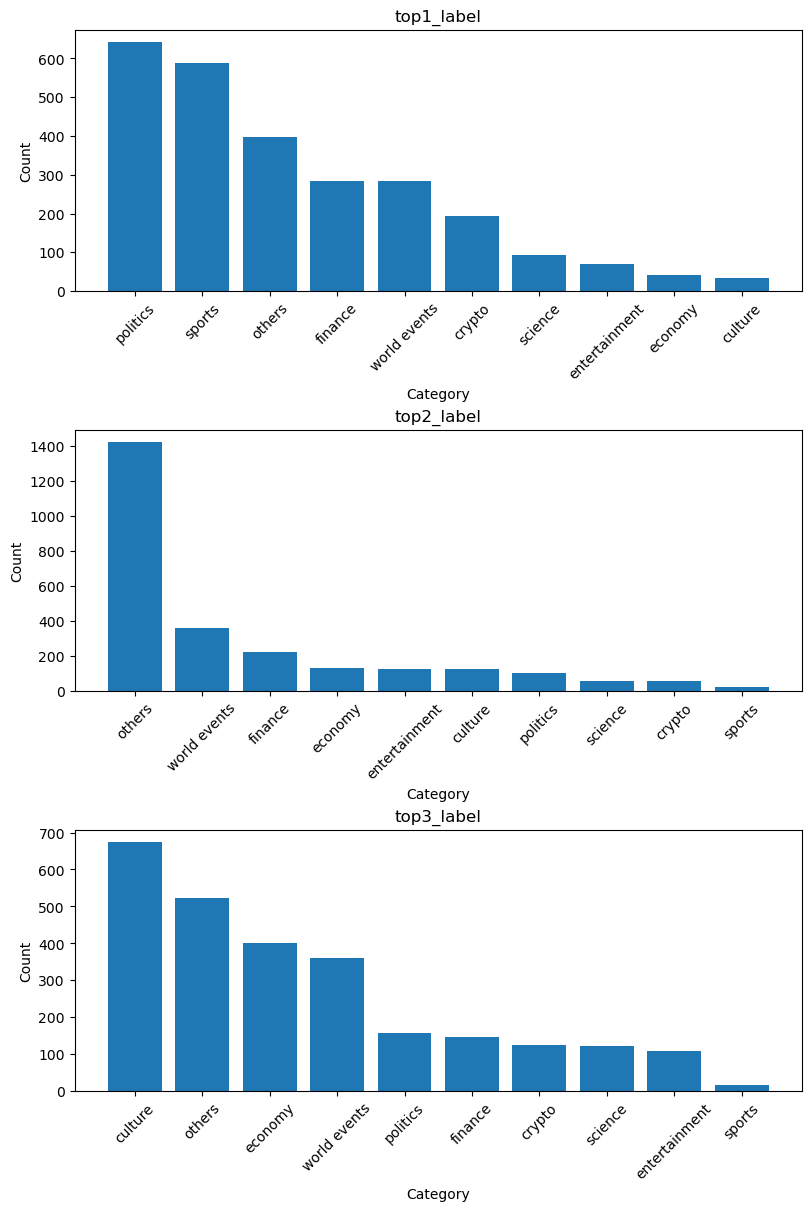

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

# Materialize once
df = df_market_class_dedup.collect()

# Pick 3 label columns automatically (contains "label" and is string/categorical)
label_cols = [
    c for c, dt in zip(df.columns, df.dtypes)
    if "label" in c.lower() and dt in (pl.Utf8, pl.Categorical, pl.Enum)
]

if len(label_cols) < 3:
    raise ValueError(f"Found only {len(label_cols)} label columns: {label_cols}")

# Choose top 3 by non-null count
top3_cols = sorted(label_cols, key=lambda c: df[c].drop_nulls().len(), reverse=True)[:3]

# Plot
fig, axes = plt.subplots(3, 1, figsize=(8, 12), constrained_layout=True)

for ax, col in zip(axes, top3_cols):
    vc = (
        df.select(pl.col(col).drop_nulls().value_counts())
        .unnest(col)
        .sort("count", descending=True)
        .head(15)  # top 15 categories for readability
    )

    labels = vc[col].to_list()
    counts = vc["count"].to_list()

    ax.bar(labels, counts)
    ax.set_title(col)
    ax.set_xlabel("Category")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

plt.show()


**Observations**  
After running the transformer classifiers, we see politics and sports being the top contents of the polymarket topics questions. The other following topics include finance, world events, and crypto.

The 2nd and 3rd rank labels do show higher "other" classification instead of more meaningful labels. Manually Observing the rows and data labels, the top 1 labels should be enough for our market category analysis.

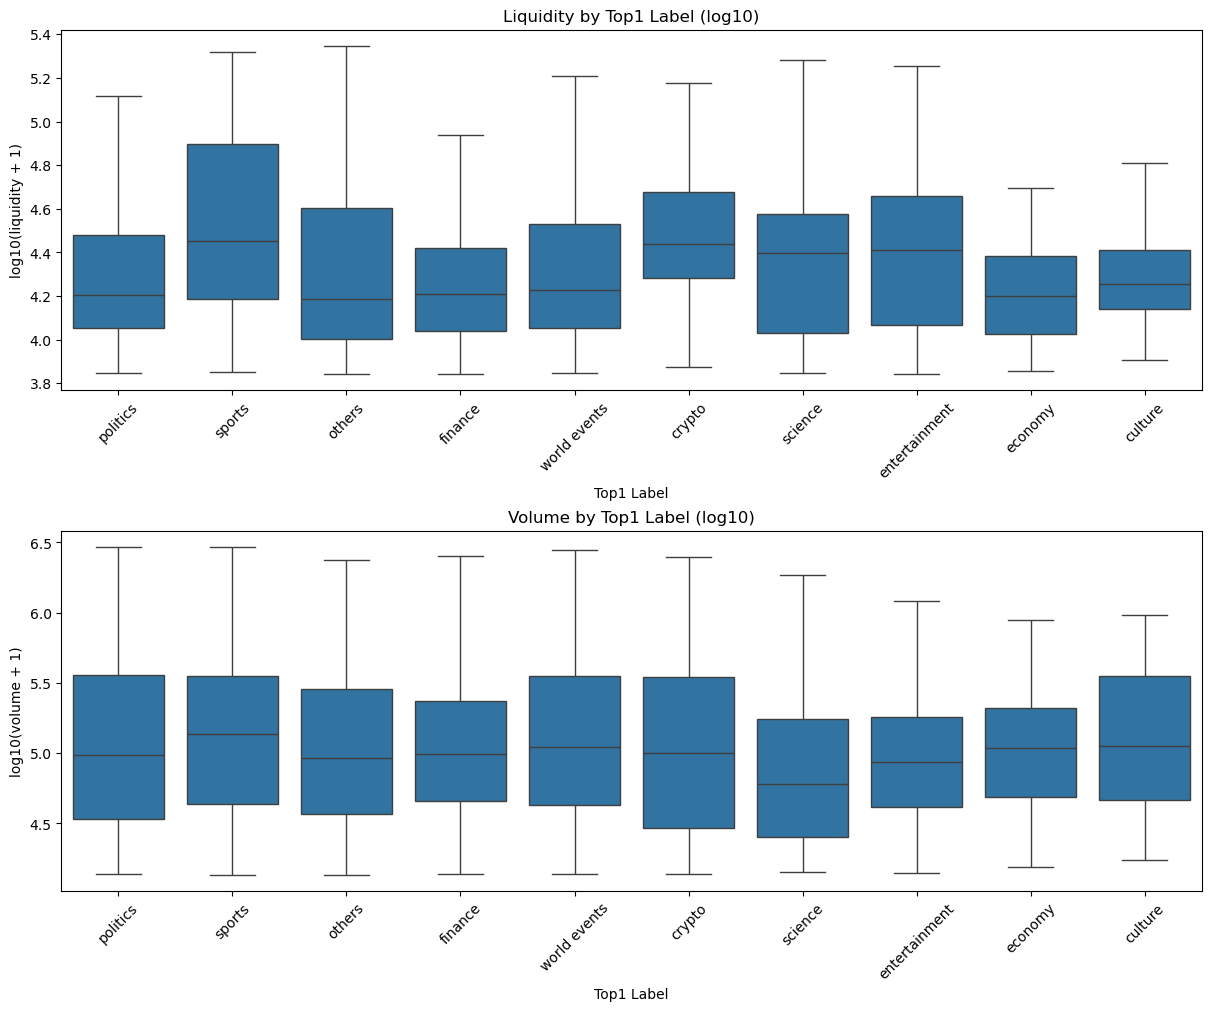

In [73]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Materialize
df = df_market_class_dedup.collect()

# Keep needed columns + clean nulls
plot_df = (
    df.select(["top1_label", "liquidity", "volume"])
      .drop_nulls()
      .to_pandas()
)

# Optional: keep only top N labels for readability
top_n = 12
top_labels = plot_df["top1_label"].value_counts().head(top_n).index
plot_df = plot_df[plot_df["top1_label"].isin(top_labels)].copy()

# Optional: log transform if highly skewed
plot_df["liquidity_log10"] = np.log10(plot_df["liquidity"] + 1)
plot_df["volume_log10"] = np.log10(plot_df["volume"] + 1)

# Order labels by frequency
order = plot_df["top1_label"].value_counts().index.tolist()

fig, axes = plt.subplots(2, 1, figsize=(12, 10), constrained_layout=True)

sns.boxplot(data=plot_df, x="top1_label", y="liquidity_log10", order=order, ax=axes[0], showfliers=False)
axes[0].set_title("Liquidity by Top1 Label (log10)")
axes[0].set_xlabel("Top1 Label")
axes[0].set_ylabel("log10(liquidity + 1)")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=plot_df, x="top1_label", y="volume_log10", order=order, ax=axes[1], showfliers=False)
axes[1].set_title("Volume by Top1 Label (log10)")
axes[1].set_xlabel("Top1 Label")
axes[1].set_ylabel("log10(volume + 1)")
axes[1].tick_params(axis="x", rotation=45)

plt.show()


## Exploring OrderBook Ticks

Filtering Target Markets again 

Rows before:  123,895
Rows after:   2,633
Rows removed: 121,262 (97.87%)


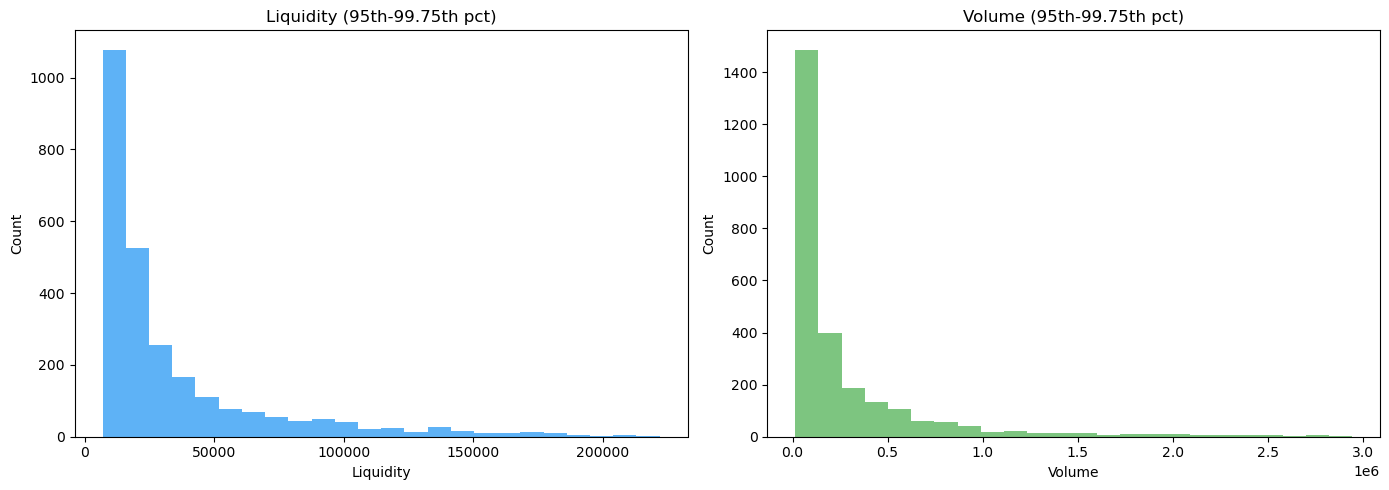

In [37]:
import numpy as np
import matplotlib.pyplot as plt

market_df = df_market.collect() if isinstance(df_market, pl.LazyFrame) else df_market

# keep middle 98% (1st to 99th percentile)
p_low, p_high = 95, 99.75
# p_low, p_high = 0, 100

liq_all = market_df["liquidity"].drop_nulls().to_numpy()
vol_all = market_df["volume"].drop_nulls().to_numpy()

liq_min, liq_max = np.percentile(liq_all, [p_low, p_high])
vol_min, vol_max = np.percentile(vol_all, [p_low, p_high])

before_rows = market_df.height

filtered = market_df.filter(
    pl.col("liquidity").is_between(liq_min, liq_max, closed="both") &
    pl.col("volume").is_between(vol_min, vol_max, closed="both")
)

after_rows = filtered.height
removed_rows = before_rows - after_rows
removed_pct = (removed_rows / before_rows * 100) if before_rows else 0.0

print(f"Rows before:  {before_rows:,}")
print(f"Rows after:   {after_rows:,}")
print(f"Rows removed: {removed_rows:,} ({removed_pct:.2f}%)")


liq = filtered["liquidity"].to_numpy()
vol = filtered["volume"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(liq, bins=24, color="#42A5F5", alpha=0.85, edgecolor="none")
axes[0].set_title(f"Liquidity ({p_low}th-{p_high}th pct)")
axes[0].set_xlabel("Liquidity")
axes[0].set_ylabel("Count")

axes[1].hist(vol, bins=24, color="#66BB6A", alpha=0.85, edgecolor="none")
axes[1].set_title(f"Volume ({p_low}th-{p_high}th pct)")
axes[1].set_xlabel("Volume")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


### Loading Orderbook Data

**Tick Aggregation Setting**  
The dataset records ticks every millisecond across all markets in Polymarket. This makes the dataset extremely huge and analysis such as market manipulation can be dependent on how this is setup. 1 minute ticks can allow quick and reactive analysis but can also be extremely noisy. 1 hour tick aggregation allows us to handle the data faster and consider the broader market but can miss short-lived manipulation.

In [117]:
'''Loads Unfiltered Data'''
# sample_file = ob_files[-2] if len(ob_files) > 1 else ob_files[0]
# sample = (
#     pl.scan_parquet(f"{DATA_DIR}/orderbook/{sample_file}")
#     .with_row_index("row_idx")
#     .filter(pl.col("row_idx") % 500 == 0)
#     .drop("row_idx")
#     .collect()
# )

# print(f"Sample: {sample.height:,} rows, {sample.width} columns")
# print(f"Columns: {sample.columns}")
# print(f"\nUnique markets in sample: {sample['market_id'].n_unique():,}")
# print(f"Time range: {sample['timestamp_received'].min()} → {sample['timestamp_received'].max()}")
# print()
# # print(sample.head(5))
# sample.head(5).to_pandas()

'''Loads Filtered Data'''
valid_condition_ids = (
    filtered
    .select(pl.col("condition_id").cast(pl.Utf8))
    .unique()
    .get_column("condition_id")
    .to_list()
)

sample_file = ob_files[-2] if len(ob_files) > 1 else ob_files[0]
sample = (
    pl.scan_parquet(f"{DATA_DIR}/orderbook/{sample_file}")
    .with_columns(pl.col("market_id").cast(pl.Utf8))
    .filter(pl.col("market_id").is_in(valid_condition_ids))
    .with_row_index("row_idx")
    .filter(pl.col("row_idx") % 100 == 0) # SET TICK AGGREGATION HERE
    .drop("row_idx")
    .collect()
)

print(f"Sample: {sample.height:,} rows, {sample.width} columns")
print(f"Columns: {sample.columns}")
print(f"\nUnique markets in sample: {sample['market_id'].n_unique():,}")
print(f"Time range: {sample['timestamp_received'].min()} -> {sample['timestamp_received'].max()}")
print()
sample.head(5).to_pandas()

Sample: 315,164 rows, 11 columns
Columns: ['timestamp_received', 'timestamp_created_at', 'market_id', 'best_bid', 'best_ask', 'change_price', 'change_size', 'change_side', 'token_id', 'spread', 'mid_price']

Unique markets in sample: 2,249
Time range: 1774396800467 -> 1774483199371



,timestamp_received,timestamp_created_at,market_id,best_bid,best_ask,change_price,change_size,change_side,token_id,spread,mid_price
0,1774396816392,1774396816403,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,0.016,0.024,0.128,0.0,SELL,4455468110807479331389362642427847115009165823...,0.008,0.0200
1,1774397367896,1774397367926,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,0.016,0.024,0.238,30.0,SELL,4455468110807479331389362642427847115009165823...,0.008,0.0200
2,1774399774973,1774399775004,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,0.016,0.024,0.186,490.0,SELL,4455468110807479331389362642427847115009165823...,0.008,0.0200
3,1774397265722,1774397265764,0x000e7d579cf57fd0b8428656d385c57f3c6e7f8e5ffe...,0.002,0.003,0.067,0.0,SELL,4601659387399734025867972420532437317622481231...,0.001,0.0025
4,1774397693899,1774397693941,0x000e7d579cf57fd0b8428656d385c57f3c6e7f8e5ffe...,0.002,0.003,0.054,0.0,SELL,4601659387399734025867972420532437317622481231...,0.001,0.0025


Median Spread Metric  
Calculates the median spread for each market sorted descending together with descending ticks.

In [39]:
# Polar Dataframe Version. Filtered to High Liquidity and Volume Markets
filtered.head(5).to_pandas()

,condition_id,question,category,end_date,closed,uma_status,volume,liquidity,clob_token_id_yes,clob_token_id_no,target
0,0xb48621f7eba07b0a3eeabc6afb09ae42490239903997...,BitBoy convicted?,,2026-03-31T12:00:00Z,False,,2.266330e+05,9631.43077,7546712961590831958303147464265888547913563043...,3842963720267267286970642336860752782302644680...,NaN
1,0x9c1a953fe92c8357f1b646ba25d983aa83e90c525992...,Russia-Ukraine Ceasefire before GTA VI?,,2026-07-31T12:00:00Z,False,,1.403228e+06,100309.56630,8501497159083948713316135768103773293754490207...,2527312495175492857904889758552137141356236738...,NaN
2,0x1fad72fae204143ff1c3035e99e7c0f65ea8d5cd9bd1...,New Rihanna Album before GTA VI?,,2026-07-31T12:00:00Z,False,,6.751036e+05,32729.52530,9802249026969240999812649612759703249033407008...,5383155306188300653073987728410593891972140877...,NaN
3,0x50ddb9cd80d5c271664a2ebb7fcaed1d0a148d82c8e8...,New Playboi Carti Album before GTA VI?,,2026-07-31T12:00:00Z,False,,7.094616e+05,29544.93060,8827504006008477337655718797221526751304984864...,9437620581602295554297963554227993296735991576...,NaN
4,0x84f8b70331323c2fba97d7ceaa9a35fb645a0770d0db...,Trump out as President before GTA VI?,,2026-07-31T12:00:00Z,False,,5.564197e+05,106972.10780,1089997232078979418764529355570116040679173891...,6453357980929752557903360996363493950101333285...,NaN


In [40]:
sample.head(5).to_pandas()

,timestamp_received,timestamp_created_at,market_id,best_bid,best_ask,change_price,change_size,change_side,token_id,spread,mid_price
0,1772755441639,1772755441679,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,0.009,0.013,0.009,1000.900024,BUY,4455468110807479331389362642427847115009165823...,0.004,0.0110
1,1772755526911,1772755526942,0x006087c5cae7b89aaa80a0c0bc6ca9bcc49ba22e95f5...,0.025,0.030,0.031,448.000000,SELL,8985524882875935477837648742652210448816704829...,0.005,0.0275
2,1772755612672,1772755612717,0x006c094eeab7dac264ed602f6a8576475d72df9a6d53...,0.014,0.021,0.117,25.000000,SELL,2623130809851989700507859235519005623449244983...,0.007,0.0175
3,1772756366701,1772756366743,0x006c094eeab7dac264ed602f6a8576475d72df9a6d53...,0.014,0.021,0.235,165.000000,SELL,2623130809851989700507859235519005623449244983...,0.007,0.0175
4,1772757256917,1772757256940,0x006c094eeab7dac264ed602f6a8576475d72df9a6d53...,0.014,0.021,0.207,20.000000,SELL,2623130809851989700507859235519005623449244983...,0.007,0.0175


In [119]:
labels = pl.read_parquet("/mnt/data/public/polymarket/labels/market_targets.parquet")

labels_lu = (
    labels
    .select(["condition_id", "question"])
    .unique(subset=["condition_id"])
    .with_columns(pl.col("condition_id").cast(pl.Utf8))
)

median_spread_table = (
    sample
    .with_columns(pl.col("market_id").cast(pl.Utf8))
    .filter(pl.col("spread") > 0)
    .group_by("market_id")
    .agg([
        pl.col("spread").median().alias("median_spread"),
        pl.len().alias("ticks"),
    ])
    .join(labels_lu, left_on="market_id", right_on="condition_id", how="left")
    .select(["market_id", "question", "median_spread", "ticks"])
    .sort(
        by=["median_spread", "ticks"],
        descending=[False, True],  # median_spread asc, ticks desc
    )
)

median_spread_table.head(10).to_pandas()

,market_id,question,median_spread,ticks
0,0x5cd80b8fd72f37c78260a4f8fa0d5bbaaad3adffcfc2...,Will Anthropic have the best AI model at the e...,0.001,307
1,0x36a8b9be52c977bf04900c61fb698dbf77ad039f2ce0...,Nothing Ever Happens: Jerome Powell Edition,0.001,60
2,0x143610d62cc5322323c2112169a2c2d81b6b2bf44a67...,Will NVIDIA be the largest company in the worl...,0.001,58
3,0x8c3455f1a9afbd5a7911fbf1c0d454359ad99f0f518d...,Will the Democratic Party of Korea (DP) win th...,0.001,49
4,0xd780578b9f953f44710e6070cc578cde6d5a8374d280...,Will a 10% US blanket tariff be in effect on M...,0.001,8
5,0xaece8d6062d3e3eb9845b32441a4ab06eb2ef332c022...,Will 4 Fed rate cuts happen in 2026?,0.001,760
6,0x066f2341d819cd15d2562bddd08b99584dcce1e546b6...,Will the US strike 6 countries in 2026?,0.001,61
7,0xf773a12cc13214fc493ec398f96c4ea5ec87ea4ff3b2...,Will Benny Gantz be the next Prime Minister of...,0.001,278
8,0x8587c25e68ea0f18372d15251bc5d6784999f44b32f6...,Will SpaceX's market cap be between $1.4T and ...,0.001,195
9,0xaf40e8cdeddd6b7a560e6aae93779f1f208a9d0aca76...,Will Elon Musk post 240-259 tweets from March ...,0.001,179


**Observation**  
Mean Spread or the difference between the highest bid and the lowest ask can help indicate liquid markets. Here we see a combination of Politics, Sports, and War Related Events tend to have higher liquidity by mean spread.

Spread Distribution

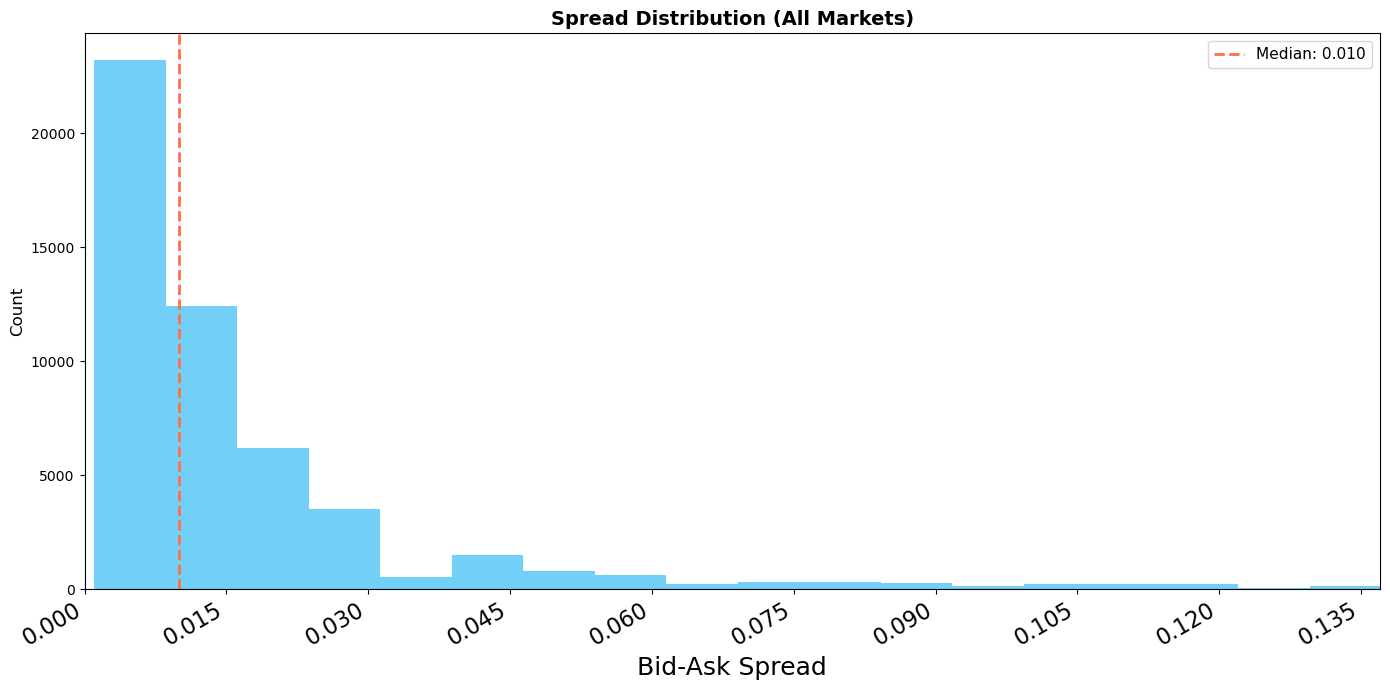

In [42]:
spreads = sample.filter(pl.col("spread") > 0)["spread"].to_numpy()

fig, ax = plt.subplots(figsize=(14, 7))

# Histogram (top plot only)
ax.hist(spreads, bins=64, color="#4FC3F7", edgecolor="none", alpha=0.8)
ax.axvline(
    np.median(spreads),
    color="#FF7043",
    linestyle="--",
    linewidth=2,
    label=f"Median: {np.median(spreads):.3f}"
)
ax.set_xlabel("Bid-Ask Spread", fontsize=18)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Spread Distribution (All Markets)", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.set_xlim(0, min(0.3, np.percentile(spreads, 99)))
ax.tick_params(axis="x", labelsize=16)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
ax.xaxis.set_major_locator(MultipleLocator(0.015))  # change step as needed

plt.tight_layout()
plt.show()


**Observation**  
By mean spread observation we see that a large number of markets have small bid-ask spread indicating competitive trading and high liquidity markets.

Statistics Check:  


In [43]:
# Basic statistics on the core price columns
print("=== Price & Spread Statistics ===")
print(sample.select([
    pl.col("best_bid").mean().alias("avg_bid"),
    pl.col("best_ask").mean().alias("avg_ask"),
    pl.col("spread").mean().alias("avg_spread"),
    pl.col("spread").median().alias("median_spread"),
    pl.col("mid_price").mean().alias("avg_mid"),
]).to_pandas().T.rename(columns={0: "Value"}))

=== Price & Spread Statistics ===
                  Value
avg_bid        0.164024
avg_ask        0.180670
avg_spread     0.016647
median_spread  0.010000
avg_mid        0.172347


In [44]:
sample.describe()

statistic,timestamp_received,timestamp_created_at,market_id,best_bid,best_ask,change_price,change_size,change_side,token_id,spread,mid_price
str,f64,f64,str,f64,f64,f64,f64,str,str,f64,f64
"""count""",51290.0,51290.0,"""51290""",51290.0,51290.0,51290.0,51290.0,"""51290""","""51290""",51290.0,51290.0
"""null_count""",0.0,0.0,"""0""",0.0,0.0,0.0,0.0,"""0""","""0""",0.0,0.0
"""mean""",1.7728e12,1.7728e12,null,0.164024,0.18067,0.328117,22681.744141,null,null,0.016647,0.172347
"""std""",2.4785e7,2.4785e7,null,0.236909,0.243523,0.302405,357664.625,null,null,0.026557,0.239872
"""min""",1.7728e12,1.7728e12,"""0x00000977017fa72fb6b1908ae694…",0.0,0.001,0.001,0.0,"""BUY""","""100043934323667825194130777434…",0.001,0.0005
"""25%""",1.7728e12,1.7728e12,null,0.008,0.015,0.073,0.0,null,null,0.002,0.0115
"""50%""",1.7728e12,1.7728e12,null,0.047,0.061,0.217,53.330002,null,null,0.01,0.055
"""75%""",1.7728e12,1.7728e12,null,0.21,0.23,0.55,489.320007,null,null,0.02,0.225
"""max""",1.7728e12,1.7728e12,"""0xffdbbf2c3b9aa808abbcb35beb2b…",0.993,0.996,0.999,1.1273395e7,"""SELL""","""999514682180077996994307140148…",0.485,0.9935


### Exploring Intraday Pattern  
How does the market change within a day?

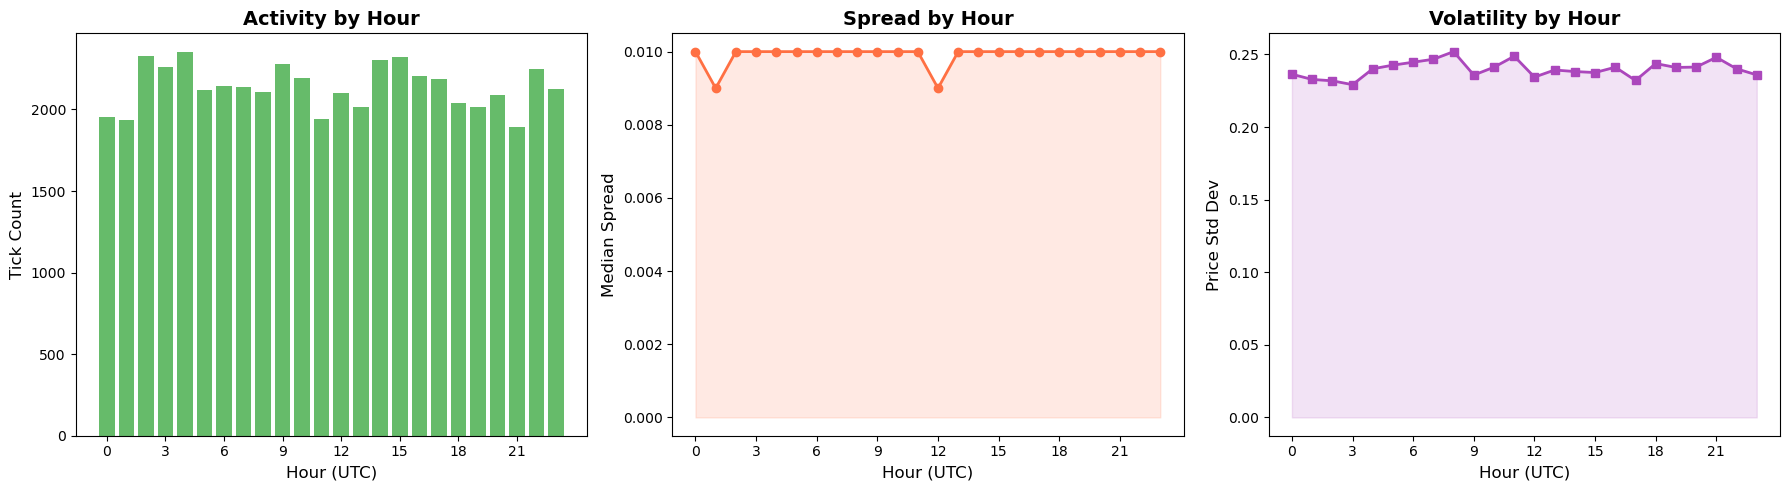

In [45]:
# Add hour-of-day column
hourly = (
    sample
    .with_columns(
        pl.from_epoch("timestamp_received", time_unit="ms")  # change if needed
        .dt.hour()
        .alias("hour")
    )
    .group_by("hour")
    .agg([
        pl.len().alias("tick_count"),
        pl.col("spread").median().alias("median_spread"),
        pl.col("mid_price").std().alias("price_volatility"),
    ])
    .sort("hour")
    .to_pandas()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Tick volume by hour
axes[0].bar(hourly["hour"], hourly["tick_count"], color="#66BB6A", edgecolor="none")
axes[0].set_xlabel("Hour (UTC)", fontsize=12)
axes[0].set_ylabel("Tick Count", fontsize=12)
axes[0].set_title("Activity by Hour", fontsize=14, fontweight="bold")
axes[0].set_xticks(range(0, 24, 3))

# Spread by hour
axes[1].plot(hourly["hour"], hourly["median_spread"], color="#FF7043", linewidth=2, marker="o")
axes[1].fill_between(hourly["hour"], hourly["median_spread"], alpha=0.15, color="#FF7043")
axes[1].set_xlabel("Hour (UTC)", fontsize=12)
axes[1].set_ylabel("Median Spread", fontsize=12)
axes[1].set_title("Spread by Hour", fontsize=14, fontweight="bold")
axes[1].set_xticks(range(0, 24, 3))

# Volatility by hour
axes[2].plot(hourly["hour"], hourly["price_volatility"], color="#AB47BC", linewidth=2, marker="s")
axes[2].fill_between(hourly["hour"], hourly["price_volatility"], alpha=0.15, color="#AB47BC")
axes[2].set_xlabel("Hour (UTC)", fontsize=12)
axes[2].set_ylabel("Price Std Dev", fontsize=12)
axes[2].set_title("Volatility by Hour", fontsize=14, fontweight="bold")
axes[2].set_xticks(range(0, 24, 3))

plt.tight_layout()
plt.show()

# Feature Engineering
Example Code of How the Features were created in ml_features_1m_v2.parquet"

In [99]:
display(sample.head(5).to_pandas())
sample_dt.select(
    pl.col("timestamp_received_dt").min().alias("received_start"),
    pl.col("timestamp_received_dt").max().alias("received_end"),
    pl.col("timestamp_created_at_dt").min().alias("created_start"),
    pl.col("timestamp_created_at_dt").max().alias("created_end"),
).to_pandas()

,timestamp_received,timestamp_created_at,market_id,best_bid,best_ask,change_price,change_size,change_side,token_id,spread,mid_price
0,1774396864076,1774396864084,0x02ca21e92cfb87c4ca0aca32c2542e73db30f0b607db...,0.010,0.018,0.521,0.0,SELL,6300600088473690257480637007512540350564351604...,0.008,0.0140
1,1774399304916,1774399304955,0x02ca21e92cfb87c4ca0aca32c2542e73db30f0b607db...,0.010,0.011,0.643,40.0,SELL,6300600088473690257480637007512540350564351604...,0.001,0.0105
2,1774398594362,1774398594454,0x02d2a7107f5a2a651e606a9600d11233a9aa83a2b93d...,0.035,0.103,0.960,0.0,SELL,3249887824082934885860235911492562551181940225...,0.068,0.0690
3,1774397599710,1774397599801,0x02ff8dfd8577449e6f21bc2fb944765a6487086fb148...,0.500,0.680,0.700,24.0,SELL,5586703430665843360847346329401792328255951521...,0.180,0.5900
4,1774400104189,1774400104195,0x0a999ae98b3c9e593cbbd33e2f940df1b071ac0ab9ed...,0.001,0.003,0.007,10.0,SELL,1512431406389066479488864274879593903000198632...,0.002,0.0020


,received_start,received_end,created_start,created_end
0,2026-03-25 00:00:07.149,2026-03-25 23:59:56.135,2026-03-25 00:00:07.767,2026-03-25 23:59:56.206


Bar Aggregation 1 Minute

Bars is a **1-minute aggregation** of tick-level market data. Each row is one (market_id, minute_bar).

- minute_bar: Minute bucket in UTC from timestamp_received (truncated to 1 minute).
- close_mid: Last mid_price observed in that minute. Proxy for minute “close” price.
- mean_spread: Average bid-ask spread across all ticks in that minute. Typical trading cost/liquidity tightness.
- close_spread: Last spread in that minute. End-of-minute liquidity snapshot.
- bar_volatility: max(mid_price) - min(mid_price) within the minute. Intraminute price range (realized movement).
- tick_count: Number of ticks in that minute (pl.len()). Activity intensity / market microstructure density.
- return_1m: Minute-over-minute percent change of close_mid within each market_id (pct_change().over("market_id")), with first/- undefined values filled to 0.0.

In [120]:
print(f"Building 1-minute bars from {sample.height:,} ticks...")

bars = (
    sample
    .with_columns(
        pl.from_epoch("timestamp_received", time_unit="ms")
        .dt.replace_time_zone("UTC")
        .dt.truncate("1m")
        .alias("minute_bar")
    )
    .group_by(["market_id", "minute_bar"])
    .agg(
        close_mid=pl.col("mid_price").last(), # collects the last close_mid price
        mean_spread=pl.col("spread").mean(),
        close_spread=pl.col("spread").last(),
        bar_volatility=(pl.col("mid_price").max() - pl.col("mid_price").min()),
        tick_count=pl.len(),
    )
    .sort(["market_id", "minute_bar"])
    .with_columns(
        return_1m=(
            pl.col("close_mid")
            .pct_change()
            .over("market_id")
            .fill_nan(0.0)
            .fill_null(0.0)
        )
    )
)

print(f"\nGenerated {bars.height:,} minute bars from {sample.height:,} ticks")
print(f"Unique markets: {bars['market_id'].n_unique():,}")
print(f"Compression ratio: {sample.height / bars.height:.0f}:1")
bars.head(10).to_pandas()


Building 1-minute bars from 315,164 ticks...

Generated 288,471 minute bars from 315,164 ticks
Unique markets: 2,249
Compression ratio: 1:1


,market_id,minute_bar,close_mid,mean_spread,close_spread,bar_volatility,tick_count,return_1m
0,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,2026-03-25 00:00:00+00:00,0.02,0.008,0.008,0.0,1,0.0
1,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,2026-03-25 00:09:00+00:00,0.02,0.008,0.008,0.0,1,0.0
2,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,2026-03-25 00:49:00+00:00,0.02,0.008,0.008,0.0,1,0.0
3,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,2026-03-25 01:12:00+00:00,0.02,0.008,0.008,0.0,1,0.0
4,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,2026-03-25 01:29:00+00:00,0.02,0.008,0.008,0.0,1,0.0
5,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,2026-03-25 01:42:00+00:00,0.02,0.008,0.008,0.0,1,0.0
6,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,2026-03-25 01:58:00+00:00,0.02,0.008,0.008,0.0,1,0.0
7,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,2026-03-25 02:09:00+00:00,0.02,0.008,0.008,0.0,1,0.0
8,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,2026-03-25 02:34:00+00:00,0.02,0.008,0.008,0.0,1,0.0
9,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,2026-03-25 02:46:00+00:00,0.02,0.008,0.008,0.0,1,0.0


Bar Aggregation 1 hour

In [121]:
bars_1h = (
    sample
    .with_columns(
        pl.from_epoch("timestamp_received", time_unit="ms")
        .dt.replace_time_zone("UTC")
        .dt.truncate("1h")
        .alias("hour_bar")
    )
    .group_by(["market_id", "hour_bar"])
    .agg(
        close_mid=pl.col("mid_price").last(),
        mean_spread=pl.col("spread").mean(),
        close_spread=pl.col("spread").last(),
        bar_volatility=(pl.col("mid_price").max() - pl.col("mid_price").min()),
        tick_count=pl.len(),
    )
    .sort(["market_id", "hour_bar"])
    .with_columns(
        return_1h=(
            pl.col("close_mid")
            .pct_change()
            .over("market_id")
            .fill_nan(0.0)
            .fill_null(0.0)
        )
    )
)

print(f"\nGenerated {bars_1h.height:,} hourly bars from {sample.height:,} ticks")
print(f"Unique markets: {bars_1h['market_id'].n_unique():,}")
print(f"Compression ratio: {sample.height / bars_1h.height:.0f}:1")
bars_1h.head(10).to_pandas()



Generated 47,397 hourly bars from 315,164 ticks
Unique markets: 2,249
Compression ratio: 7:1


,market_id,hour_bar,close_mid,mean_spread,close_spread,bar_volatility,tick_count,return_1h
0,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,2026-03-25 00:00:00+00:00,0.0200,0.008000,0.008,0.0000,3,0.000
1,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,2026-03-25 01:00:00+00:00,0.0200,0.008000,0.008,0.0000,4,0.000
2,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,2026-03-25 02:00:00+00:00,0.0200,0.008000,0.008,0.0000,4,0.000
3,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,2026-03-25 03:00:00+00:00,0.0200,0.008000,0.008,0.0000,6,0.000
4,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,2026-03-25 04:00:00+00:00,0.0200,0.007800,0.008,0.0005,5,0.000
5,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,2026-03-25 05:00:00+00:00,0.0200,0.008000,0.008,0.0000,3,0.000
6,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,2026-03-25 06:00:00+00:00,0.0200,0.008000,0.008,0.0000,4,0.000
7,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,2026-03-25 07:00:00+00:00,0.0200,0.006462,0.006,0.0010,13,0.000
8,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,2026-03-25 08:00:00+00:00,0.0200,0.006949,0.008,0.0010,39,0.000
9,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,2026-03-25 09:00:00+00:00,0.0165,0.004938,0.003,0.0055,32,-0.175


# Exploring Trades Data
Trades data records actual completed exchanges of YES/NO Tokens  

**Market Resolution Analysis**  
How often did the predictions not meet the market resolutions?

Loading Only Resolved Market Information

In [122]:
import polars as pl

trades = pl.scan_parquet("/mnt/data/public/polymarket/labels/trades.parquet")
targets = pl.scan_parquet("/mnt/data/public/polymarket/labels/market_targets.parquet")

resolved_markets_lf = (
    targets
    .filter((pl.col("closed") == True) & (pl.col("target").is_not_null()))
    .with_columns(pl.col("condition_id").cast(pl.Utf8))
)

resolved_trades_lf = (
    trades
    .with_columns(pl.col("condition_id").cast(pl.Utf8))
    .join(
        resolved_markets_lf.select("condition_id").unique(),
        on="condition_id",
        how="inner"
    )
)

df_resolved_markets = resolved_markets_lf.collect().to_pandas()   # full market rows
df_resolved_trades = resolved_trades_lf.collect().to_pandas()     # trades for those markets

Filtering Non-Valuable Markets where no Trade is Happening

Rows before:  23,146
Rows after:   1,134
Rows removed: 22,012 (95.10%)


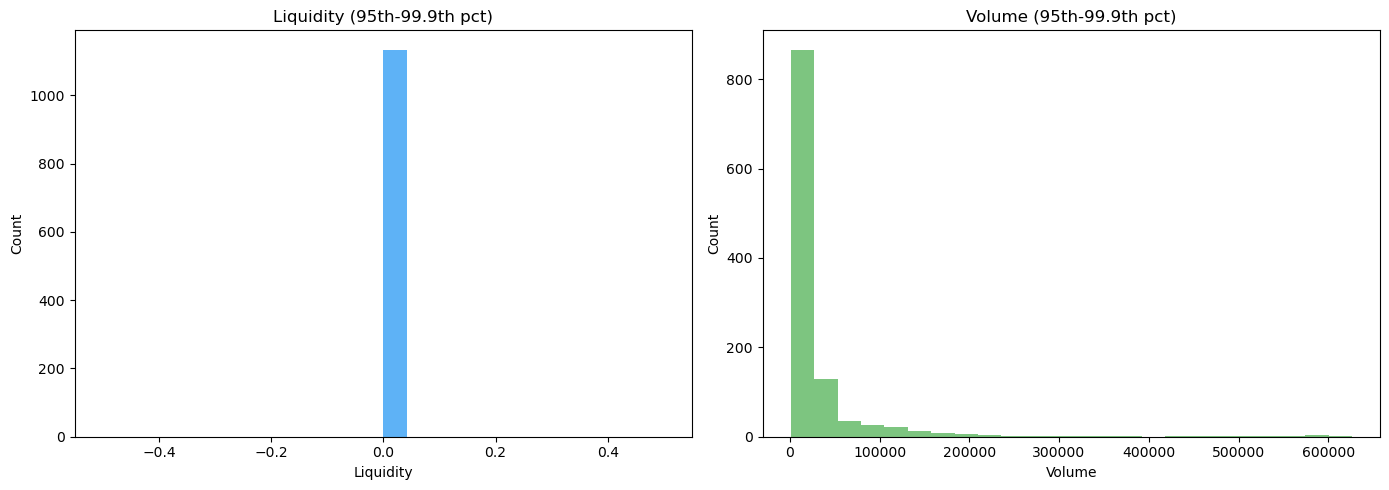

,volume,liquidity,target
count,1134.000000,1134.0,1134.000000
mean,31381.354146,0.0,0.254850
std,72654.680398,0.0,0.435969
min,1147.263155,0.0,0.000000
25%,3897.639931,0.0,0.000000
50%,9813.263159,0.0,0.000000
75%,25098.031581,0.0,1.000000
max,626396.935658,0.0,1.000000


,condition_id,question,category,end_date,closed,uma_status,volume,liquidity,clob_token_id_yes,clob_token_id_no,target
17,0x99716e41bd8caea0c1a3a8218b3933da1fb695e78a72...,Will the Utah Jazz win the NBA Western Confere...,,2026-06-16T00:00:00Z,True,resolved,53886.739146,0.0,7987068510404627270135653986433677523355505372...,9270412501890989927672258696136170720133096748...,0
46,0x8bf0f49f222c7dc95e4c62b78def2e6c0f1fd4eae210...,Will Brest win the 2025–26 French Ligue 1?,,2026-05-30T00:00:00Z,True,resolved,155614.167583,0.0,1082322041868847629327781188965548642014096750...,2314489654017663359858325336492189945404226397...,0
47,0x71da12db4aea759acbf68b2777c44b21caf6a5ee9ac3...,Will PH win the most seats in the 2026 Colombi...,,2026-03-08T20:00:00Z,True,resolved,425274.442432,0.0,2686131470721097539156092163606560970931014640...,1025948598894154304612162470093572929081312601...,1
48,0x9873e438b51f8a9586fbc0b629ca92ec74d02ac3ef80...,Will Conservative win the most seats in the 20...,,2026-03-08T20:00:00Z,True,resolved,161042.776576,0.0,1015673175428614311224932507904292040600878291...,9601947962690671859445335835150992235827714026...,0
51,0x0a999ae98b3c9e593cbbd33e2f940df1b071ac0ab9ed...,Will CD win the most seats in the 2026 Colombi...,,2026-03-08T20:00:00Z,True,resolved,224826.243043,0.0,1512431406389066479488864274879593903000198632...,1013849706844741467052508800382458988790206324...,0


In [49]:
import numpy as np
import matplotlib.pyplot as plt

# df_resolved_markets is already pandas
df_resolved_markets_2 = df_resolved_markets.copy()

# keep middle band
p_low, p_high = 95, 99.9
# p_low, p_high = 0, 100

liq_all = df_resolved_markets_2["liquidity"].dropna().to_numpy()
vol_all = df_resolved_markets_2["volume"].dropna().to_numpy()

liq_min, liq_max = np.percentile(liq_all, [p_low, p_high])
vol_min, vol_max = np.percentile(vol_all, [p_low, p_high])

before_rows = len(df_resolved_markets_2)

df_resolved_markets_filtered = df_resolved_markets_2[
    df_resolved_markets_2["liquidity"].between(liq_min, liq_max, inclusive="both") &
    df_resolved_markets_2["volume"].between(vol_min, vol_max, inclusive="both")
]

after_rows = len(df_resolved_markets_filtered)
removed_rows = before_rows - after_rows
removed_pct = (removed_rows / before_rows * 100) if before_rows else 0.0

print(f"Rows before:  {before_rows:,}")
print(f"Rows after:   {after_rows:,}")
print(f"Rows removed: {removed_rows:,} ({removed_pct:.2f}%)")

liq = df_resolved_markets_filtered["liquidity"].to_numpy()
vol = df_resolved_markets_filtered["volume"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(liq, bins=24, color="#42A5F5", alpha=0.85, edgecolor="none")
axes[0].set_title(f"Liquidity ({p_low}th-{p_high}th pct)")
axes[0].set_xlabel("Liquidity")
axes[0].set_ylabel("Count")

axes[1].hist(vol, bins=24, color="#66BB6A", alpha=0.85, edgecolor="none")
axes[1].set_title(f"Volume ({p_low}th-{p_high}th pct)")
axes[1].set_xlabel("Volume")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()
display(df_resolved_markets_filtered.describe())
display(df_resolved_markets_filtered.head(5))


In [50]:
df_resolved_trades.head(5)

,condition_id,side,outcome,price,size,timestamp,asset
0,0x0000dbb9f89318fa1324d4eed3dbc1ff192e764138c7...,BUY,No,0.790000,37.974682,1773535485,5475751391326417034909210895395778447254138036...
1,0x0000dbb9f89318fa1324d4eed3dbc1ff192e764138c7...,BUY,Yes,0.850000,5.000000,1773554079,8945166516904290673857818127174024824733820142...
2,0x0000dbb9f89318fa1324d4eed3dbc1ff192e764138c7...,BUY,Yes,0.850000,1.176466,1773569429,8945166516904290673857818127174024824733820142...
3,0x0000dbb9f89318fa1324d4eed3dbc1ff192e764138c7...,BUY,Yes,0.820000,1.219511,1773594139,8945166516904290673857818127174024824733820142...
4,0x0000dbb9f89318fa1324d4eed3dbc1ff192e764138c7...,BUY,No,0.540179,20.363634,1773636999,5475751391326417034909210895395778447254138036...


Selecting Parquet Files to Load  
Set to Load All to see all winning outcomes

In [51]:
import os
import re
from datetime import datetime

# Reuse existing spark session
# spark = SparkSession.builder...getOrCreate()

DATA_DIR = "/mnt/data/public/polymarket"
ob_dir = f"{DATA_DIR}/orderbook"
snap_dir = f"{DATA_DIR}/snapshots"

# -----------------------------
# Date filter options
# -----------------------------
# Option A: inclusive range
START_DATE = "2026-03-06"   # set None to disable
END_DATE   = "2026-03-06"   # set None to disable
START_DATE = None   # set None to disable
END_DATE   = None  # set None to disable

# Option B: explicit date set (takes priority if not None)
INCLUDE_DATES = None
# Example:
# INCLUDE_DATES = {"2026-03-01", "2026-03-03", "2026-03-06"}

date_pattern = re.compile(r"(\d{4}-\d{2}-\d{2})")

def extract_date(fname: str):
    m = date_pattern.search(fname)
    return m.group(1) if m else None

def keep_file_by_date(fname: str):
    d = extract_date(fname)
    if d is None:
        return False

    if INCLUDE_DATES is not None:
        return d in INCLUDE_DATES

    if START_DATE is None and END_DATE is None:
        return True

    dt = datetime.strptime(d, "%Y-%m-%d").date()
    if START_DATE is not None and dt < datetime.strptime(START_DATE, "%Y-%m-%d").date():
        return False
    if END_DATE is not None and dt > datetime.strptime(END_DATE, "%Y-%m-%d").date():
        return False
    return True

# Orderbook files filtered by date
ob_files_all = sorted([f for f in os.listdir(ob_dir) if f.endswith(".parquet")])
ob_files = [f for f in ob_files_all if keep_file_by_date(f)]
assert ob_files, "No orderbook parquet files matched your date filter."

print(f"Selected orderbook files: {len(ob_files)}")
for f in ob_files[:10]:
    print(" ", f)
if len(ob_files) > 10:
    print(" ...")

# Build full paths and read with Spark
ob_paths = [f"{ob_dir}/{f}" for f in ob_files]

Selected orderbook files: 21
  orderbook_2026-03-06.parquet
  orderbook_2026-03-07.parquet
  orderbook_2026-03-08.parquet
  orderbook_2026-03-09.parquet
  orderbook_2026-03-10.parquet
  orderbook_2026-03-11.parquet
  orderbook_2026-03-12.parquet
  orderbook_2026-03-13.parquet
  orderbook_2026-03-14.parquet
  orderbook_2026-03-15.parquet
 ...


Viewing Some of the Loaded Parquet Files

In [74]:
import polars as pl

'''Loads Filtered Data'''
valid_condition_ids = (
    df_resolved_markets_filtered["condition_id"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

sample_file = ob_files[-2] if len(ob_files) > 1 else ob_files[0]
sample = (
    pl.scan_parquet(f"{DATA_DIR}/orderbook/{sample_file}")
    .with_columns(pl.col("market_id").cast(pl.Utf8))
    .filter(pl.col("market_id").is_in(valid_condition_ids))
    .with_row_index("row_idx")
    .filter(pl.col("row_idx") % 500 == 0)
    .drop("row_idx")
    .collect()
)

print(f"Sample: {sample.height:,} rows, {sample.width} columns")
print(f"Columns: {sample.columns}")
print(f"\nUnique markets in sample: {sample['market_id'].n_unique():,}")
print(f"Time range: {sample['timestamp_received'].min()} -> {sample['timestamp_received'].max()}")
sample.head(5).to_pandas()


Sample: 4,712 rows, 11 columns
Columns: ['timestamp_received', 'timestamp_created_at', 'market_id', 'best_bid', 'best_ask', 'change_price', 'change_size', 'change_side', 'token_id', 'spread', 'mid_price']

Unique markets in sample: 166
Time range: 1774396807149 -> 1774483196135


,timestamp_received,timestamp_created_at,market_id,best_bid,best_ask,change_price,change_size,change_side,token_id,spread,mid_price
0,1774396864076,1774396864084,0x02ca21e92cfb87c4ca0aca32c2542e73db30f0b607db...,0.010,0.018,0.521,0.0,SELL,6300600088473690257480637007512540350564351604...,0.008,0.0140
1,1774399304916,1774399304955,0x02ca21e92cfb87c4ca0aca32c2542e73db30f0b607db...,0.010,0.011,0.643,40.0,SELL,6300600088473690257480637007512540350564351604...,0.001,0.0105
2,1774398594362,1774398594454,0x02d2a7107f5a2a651e606a9600d11233a9aa83a2b93d...,0.035,0.103,0.960,0.0,SELL,3249887824082934885860235911492562551181940225...,0.068,0.0690
3,1774397599710,1774397599801,0x02ff8dfd8577449e6f21bc2fb944765a6487086fb148...,0.500,0.680,0.700,24.0,SELL,5586703430665843360847346329401792328255951521...,0.180,0.5900
4,1774400104189,1774400104195,0x0a999ae98b3c9e593cbbd33e2f940df1b071ac0ab9ed...,0.001,0.003,0.007,10.0,SELL,1512431406389066479488864274879593903000198632...,0.002,0.0020


Calculating **last_close_mid** for each market_id. The last_close_mid price is the last recorded midpoint between the best bid and best ask. It can be used as an estimated market price for the YES token and as the market-implied probability of the YES outcome.

In [75]:
import polars as pl

# If df_resolved_markets_filtered is pandas:
resolved_ids = pl.from_pandas(
    df_resolved_markets_filtered[["condition_id"]]
).with_columns(
    pl.col("condition_id").cast(pl.Utf8).alias("market_id")
).select("market_id").unique()

# If it's already Polars, use this instead:
# resolved_ids = (
#     df_resolved_markets_filtered
#     .select(pl.col("condition_id").cast(pl.Utf8).alias("market_id"))
#     .unique()
# )

sample_matched = (
    sample
    .with_columns(pl.col("market_id").cast(pl.Utf8))
    .join(resolved_ids, on="market_id", how="inner")
)

bars_matched = (
    sample_matched
    .with_columns(
        pl.from_epoch("timestamp_received", time_unit="ms")
        .dt.replace_time_zone("UTC")
        .dt.truncate("1m")
        .alias("minute_bar")
    )
    .group_by(["market_id", "minute_bar"])
    .agg(
        close_mid=pl.col("mid_price").last(),
        mean_spread=pl.col("spread").mean(),
        close_spread=pl.col("spread").last(),
        bar_volatility=(pl.col("mid_price").max() - pl.col("mid_price").min()),
        tick_count=pl.len(),
    )
    .sort(["market_id", "minute_bar"])
)

print("Matched ticks:", sample_matched.height)
print("Matched markets:", bars_matched["market_id"].n_unique())
bars_matched.head(10).to_pandas()
last_close_per_market = (
    bars_matched
    .sort(["market_id", "minute_bar"])
    .group_by("market_id")
    .agg(
        pl.col("minute_bar").last().alias("last_minute_bar"),
        pl.col("close_mid").last().alias("last_close_mid"),
    )
)

last_close_per_market.head(10).to_pandas()

Matched ticks: 4712
Matched markets: 166


,market_id,last_minute_bar,last_close_mid
0,0x0269a85841fda2b81389566a6bb2facb704842272b18...,2026-03-25 15:53:00+00:00,0.1800
1,0x02ca21e92cfb87c4ca0aca32c2542e73db30f0b607db...,2026-03-25 16:00:00+00:00,0.0060
2,0x02d2a7107f5a2a651e606a9600d11233a9aa83a2b93d...,2026-03-25 23:51:00+00:00,0.0880
3,0x02ff8dfd8577449e6f21bc2fb944765a6487086fb148...,2026-03-25 23:45:00+00:00,0.6400
4,0x036bbefd634edecdc022dc9cf7112b3d0eaccb729631...,2026-03-25 16:01:00+00:00,0.4400
5,0x04a9e35fcde589be7a66065b61c64b770d04b9133ac1...,2026-03-25 15:54:00+00:00,0.2350
6,0x05cae767acd98ec3fb6e865d8cd6c24083afeae7210c...,2026-03-25 13:18:00+00:00,0.4450
7,0x089c76d3b105c9b0739786591eda4dbf014fce1ae5b0...,2026-03-25 16:00:00+00:00,0.3400
8,0x0a999ae98b3c9e593cbbd33e2f940df1b071ac0ab9ed...,2026-03-25 23:45:00+00:00,0.0020
9,0x0ca78cc8a4067fb993ec77c0f48d9717e6d8c4b1d2f9...,2026-03-25 15:28:00+00:00,0.0035


Combining last_close_mid with the market_targets data

In [76]:
import polars as pl

resolved_with_last_close = (
    pl.from_pandas(df_resolved_markets_filtered)
    .with_columns(pl.col("condition_id").cast(pl.Utf8))
    .join(
        last_close_per_market.select(
            pl.col("market_id").cast(pl.Utf8),
            pl.col("last_close_mid")
        ),
        left_on="condition_id",
        right_on="market_id",
        how="left"
    )
)

df_resolved_markets_with_last_close = resolved_with_last_close.to_pandas()
df_resolved_markets_with_last_close.head(5)

,condition_id,question,category,end_date,closed,uma_status,volume,liquidity,clob_token_id_yes,clob_token_id_no,target,last_close_mid
0,0x99716e41bd8caea0c1a3a8218b3933da1fb695e78a72...,Will the Utah Jazz win the NBA Western Confere...,,2026-06-16T00:00:00Z,True,resolved,53886.739146,0.0,7987068510404627270135653986433677523355505372...,9270412501890989927672258696136170720133096748...,0,NaN
1,0x8bf0f49f222c7dc95e4c62b78def2e6c0f1fd4eae210...,Will Brest win the 2025–26 French Ligue 1?,,2026-05-30T00:00:00Z,True,resolved,155614.167583,0.0,1082322041868847629327781188965548642014096750...,2314489654017663359858325336492189945404226397...,0,NaN
2,0x71da12db4aea759acbf68b2777c44b21caf6a5ee9ac3...,Will PH win the most seats in the 2026 Colombi...,,2026-03-08T20:00:00Z,True,resolved,425274.442432,0.0,2686131470721097539156092163606560970931014640...,1025948598894154304612162470093572929081312601...,1,0.9970
3,0x9873e438b51f8a9586fbc0b629ca92ec74d02ac3ef80...,Will Conservative win the most seats in the 20...,,2026-03-08T20:00:00Z,True,resolved,161042.776576,0.0,1015673175428614311224932507904292040600878291...,9601947962690671859445335835150992235827714026...,0,0.0015
4,0x0a999ae98b3c9e593cbbd33e2f940df1b071ac0ab9ed...,Will CD win the most seats in the 2026 Colombi...,,2026-03-08T20:00:00Z,True,resolved,224826.243043,0.0,1512431406389066479488864274879593903000198632...,1013849706844741467052508800382458988790206324...,0,0.0020


Sigmoid Plot of last_close_mid price and actual market resolved outcome

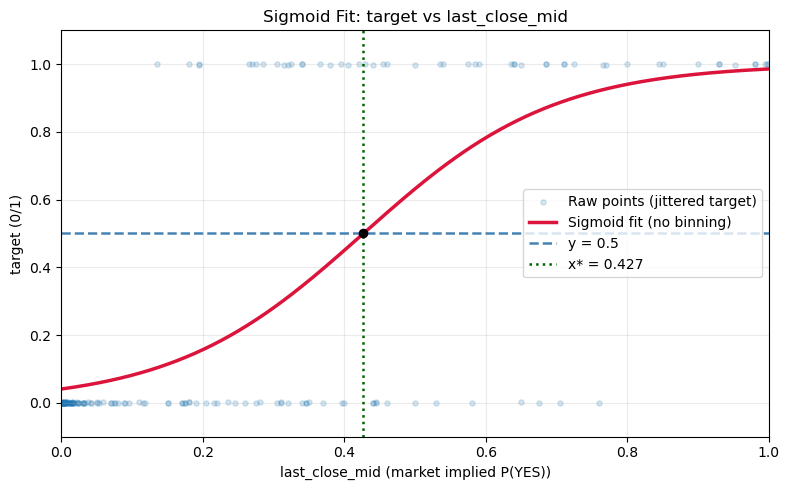

Sigmoid-0.5 intersection x*: 0.426918


In [77]:
import numpy as np
import matplotlib.pyplot as plt

# expects: df_resolved_markets_with_last_close with columns ['target', 'last_close_mid']
dfp = df_resolved_markets_with_last_close[["target", "last_close_mid"]].dropna().copy()

x = dfp["last_close_mid"].astype(float).to_numpy()
y = dfp["target"].astype(float).to_numpy()

# jitter y for visibility (since target is 0/1)
rng = np.random.default_rng(42)
y_jitter = y + rng.normal(0, 0.001, size=len(y))

# Fit logistic curve with simple gradient descent (no binning)
w, b = 0.0, 5.0
lr = 0.1
epochs = 100000

for _ in range(epochs):
    z = w * x + b
    p = 1 / (1 + np.exp(-z))
    dw = np.mean((p - y) * x)
    db = np.mean(p - y)
    w -= lr * dw
    b -= lr * db

xx = np.linspace(0, 1, 400)
yy = 1 / (1 + np.exp(-(w * xx + b)))

# Intersection with y=0.5: solve sigmoid(w*x+b)=0.5 -> w*x+b=0
x_star = -b / w if abs(w) > 1e-12 else np.nan
x_star_plot = np.clip(x_star, 0, 1) if np.isfinite(x_star) else np.nan

plt.figure(figsize=(8, 5))
plt.scatter(x, y_jitter, alpha=0.18, s=14, label="Raw points (jittered target)")
plt.plot(xx, yy, color="crimson", linewidth=2.5, label="Sigmoid fit (no binning)")

# horizontal line at y=0.5
plt.axhline(0.5, color="steelblue", linestyle="--", linewidth=1.8, label="y = 0.5")

# optional vertical line at intersection
if np.isfinite(x_star_plot):
    plt.axvline(x_star_plot, color="darkgreen", linestyle=":", linewidth=1.8,
                label=f"x* = {x_star_plot:.3f}")
    plt.scatter([x_star_plot], [0.5], color="black", s=35, zorder=5)

plt.xlabel("last_close_mid (market implied P(YES))")
plt.ylabel("target (0/1)")
plt.title("Sigmoid Fit: target vs last_close_mid")
plt.ylim(-0.1, 1.1)
plt.xlim(0, 1)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Sigmoid-0.5 intersection x*: {x_star:.6f}")


Confusion Matrix and Accuracy Evaluation

In [56]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# expects columns: target (0/1), last_close_mid (float 0..1)
df_eval = df_resolved_markets_with_last_close[["target", "last_close_mid"]].dropna().copy()

y_true = df_eval["target"].astype(int).to_numpy()
y_pred = (df_eval["last_close_mid"].astype(float).to_numpy() > 0.5).astype(int)  # above 0.5 => YES
# y_pred = (df_eval["last_close_mid"].astype(float).to_numpy() > 0.427).astype(int)  # above 0.5 => YES


cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

cm_df = pd.DataFrame(
    cm,
    index=["Actual NO (0)", "Actual YES (1)"],
    columns=["Pred NO (0)", "Pred YES (1)"]
)

print("Confusion Matrix (threshold: > 0.5 => YES)")
print(cm_df)
print()
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print()
print(classification_report(y_true, y_pred, target_names=["NO", "YES"]))


Confusion Matrix (threshold: > 0.5 => YES)
                Pred NO (0)  Pred YES (1)
Actual NO (0)           108             6
Actual YES (1)           24            28

TN=108, FP=6, FN=24, TP=28
Accuracy: 0.8193

              precision    recall  f1-score   support

          NO       0.82      0.95      0.88       114
         YES       0.82      0.54      0.65        52

    accuracy                           0.82       166
   macro avg       0.82      0.74      0.76       166
weighted avg       0.82      0.82      0.81       166



**Observation**  
Using a threshold where last_close_mid > 0.5 predicts YES and last_close_mid <= 0.5 predicts NO, the model achieved an overall accuracy of 81.93%. This suggests that the final midpoint price is a useful indicator of the resolved market outcome.

However, the model performs much better at identifying markets that resolve NO than markets that resolve YES. The NO class has a recall of 95%, meaning 108 out of 114 actual NO outcomes were correctly predicted. The YES class has a lower recall of 54%, meaning only 28 out of 52 actual YES outcomes were correctly predicted, while 24 YES outcomes were incorrectly classified as NO.

This indicates that the last_close_mid > 0.5 rule is conservative for predicting YES. It is highly effective at avoiding false YES predictions, but it misses a significant number of actual YES outcomes.

## TimeSeries Analysis

In [ ]:
print("Date Range Selected")
display(bars.select(
    pl.col("minute_bar").min().alias("start_date"),
    pl.col("minute_bar").max().alias("end_date")
).to_pandas())

Date Range Selected


,start_date,end_date
0,2026-03-06 00:00:00+00:00,2026-03-06 23:59:00+00:00


Loads Time Series of 1 hour Bar Aggregation

In [126]:
bars.head(10).to_pandas()

,market_id,minute_bar,close_mid,mean_spread,close_spread,bar_volatility,tick_count,return_1m
0,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,2026-03-25 00:00:00+00:00,0.02,0.008,0.008,0.0,1,0.0
1,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,2026-03-25 00:09:00+00:00,0.02,0.008,0.008,0.0,1,0.0
2,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,2026-03-25 00:49:00+00:00,0.02,0.008,0.008,0.0,1,0.0
3,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,2026-03-25 01:12:00+00:00,0.02,0.008,0.008,0.0,1,0.0
4,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,2026-03-25 01:29:00+00:00,0.02,0.008,0.008,0.0,1,0.0
5,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,2026-03-25 01:42:00+00:00,0.02,0.008,0.008,0.0,1,0.0
6,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,2026-03-25 01:58:00+00:00,0.02,0.008,0.008,0.0,1,0.0
7,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,2026-03-25 02:09:00+00:00,0.02,0.008,0.008,0.0,1,0.0
8,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,2026-03-25 02:34:00+00:00,0.02,0.008,0.008,0.0,1,0.0
9,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,2026-03-25 02:46:00+00:00,0.02,0.008,0.008,0.0,1,0.0


In [127]:
bars_1h.head().to_pandas()

,market_id,hour_bar,close_mid,mean_spread,close_spread,bar_volatility,tick_count,return_1h
0,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,2026-03-25 00:00:00+00:00,0.02,0.0080,0.008,0.0000,3,0.0
1,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,2026-03-25 01:00:00+00:00,0.02,0.0080,0.008,0.0000,4,0.0
2,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,2026-03-25 02:00:00+00:00,0.02,0.0080,0.008,0.0000,4,0.0
3,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,2026-03-25 03:00:00+00:00,0.02,0.0080,0.008,0.0000,6,0.0
4,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,2026-03-25 04:00:00+00:00,0.02,0.0078,0.008,0.0005,5,0.0


Time Series Plotting 1 hour aggregation of feature engineered metrics  
Data is also color-coded/categorized by topic label

In [128]:
import polars as pl
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# bars: minute-level features
# filtered: includes condition_id + question
# df_market_class_dedup: includes condition_id + top1_label

# 0) Build market_id -> question lookup
question_lu = (
    filtered
    .select([
        pl.col("condition_id").cast(pl.Utf8).alias("market_id"),
        pl.col("question")
    ])
    .drop_nulls(["market_id", "question"])
    .unique(subset=["market_id"], keep="first")
)

# 0b) Build market_id -> top1_label lookup from df_market_class_dedup  <-- NEW
topic_lu = (
    df_market_class_dedup
    .collect()  # remove if already materialized as eager Polars DF
    .select([
        pl.col("condition_id").cast(pl.Utf8).alias("market_id"),
        pl.col("top1_label")
    ])
    .drop_nulls(["market_id"])
    .unique(subset=["market_id"], keep="first")
)

# 1) Attach question + topic label to bars  <-- UPDATED
bars_labeled = (
    bars_1h
    .with_columns(pl.col("market_id").cast(pl.Utf8))
    .join(question_lu, on="market_id", how="left")
    .join(topic_lu, on="market_id", how="left")
    .with_columns([
        pl.when(pl.col("question").is_null())
          .then(pl.lit("Unknown question"))
          .otherwise(pl.col("question"))
          .alias("question"),
        pl.when(pl.col("top1_label").is_null())
          .then(pl.lit("Unknown"))
          .otherwise(pl.col("top1_label"))
          .alias("top1_label")
    ])
)

# 2) Pick markets
market_meta = (
    bars_labeled
    .select(["market_id", "question", "top1_label"])
    .unique()
    .sort("market_id")
)

market_ids = market_meta["market_id"].to_list()
questions = market_meta["question"].to_list()
topics = market_meta["top1_label"].to_list()

market_idx_list = None
market_idx_range = (0, 100)

if market_idx_list is not None:
    selected_idx = market_idx_list
elif market_idx_range is not None:
    start, end = market_idx_range
    selected_idx = list(range(start, end + 1))
else:
    raise ValueError("Set either market_idx_list or market_idx_range.")

selected_idx = [i for i in selected_idx if 0 <= i < len(market_ids)]
if not selected_idx:
    raise ValueError("No valid market indices selected.")

selected_market_ids = [market_ids[i] for i in selected_idx]

mkt = (
    bars_labeled
    .filter(pl.col("market_id").is_in(selected_market_ids))
    .sort(["market_id", "hour_bar"])
)

exclude_cols = {"market_id", "hour_bar", "question", "top1_label"}
features = [c for c, dt in mkt.schema.items() if c not in exclude_cols and dt.is_numeric()]
n = len(features)
if n == 0:
    raise ValueError("No numeric features found to plot.")

# Color map by topic label  <-- NEW
unique_topics = mkt.select("top1_label").unique().to_series().to_list()
palette = px.colors.qualitative.Plotly
color_map = {t: palette[i % len(palette)] for i, t in enumerate(unique_topics)}

fig = make_subplots(
    rows=n, cols=1, shared_xaxes=True, vertical_spacing=0.03, subplot_titles=features
)

# track which topics already appeared in legend
seen_topics = set()

for r, feat in enumerate(features, start=1):
    for mid in selected_market_ids:
        one = mkt.filter(pl.col("market_id") == mid).sort("hour_bar")
        if one.height == 0:
            continue

        topic = one["top1_label"][0]
        q = one["question"][0]
        label = (q[:70] + "...") if len(q) > 70 else q

        fig.add_trace(
            go.Scatter(
                x=one["hour_bar"].to_list(),
                y=one[feat].to_list(),
                mode="lines",
                name=topic,                         # legend text = label only
                legendgroup=topic,                 # group by topic
                showlegend=(r == 1 and topic not in seen_topics),  # one entry/topic
                line=dict(width=1.5, color=color_map.get(topic, "#888")),
                hovertemplate=(
                    f"topic: {topic}<br>"
                    f"question: {label}<br>"
                    "time: %{x}<br>"
                    f"{feat}: %{{y}}<extra></extra>"
                ),
            ),
            row=r, col=1
        )

        if r == 1:
            seen_topics.add(topic)
    fig.update_yaxes(title_text=feat, row=r, col=1)

fig.update_layout(
    height=max(350 * n, 650),
    width=800,
    title=f"Feature Time Series for {len(selected_market_ids)} Market(s)",
    legend_title="Top1 Label | Market",
    template="plotly_white",
)

fig.update_xaxes(title_text="Time (hour_bar)", row=n, col=1)
fig.show()


Pl

# Market Manipulation Methodology

Hypothesis: Can we use ______ methods to determine if the markets are being manipulated?